In [17]:
import qiskit
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram,plot_distribution
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import UGate
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pylatexenc
import numpy as np
import math
import os

In [18]:
api_key = os.getenv("API_KEY")
crn = os.getenv("CRN")
QiskitRuntimeService.save_account(
token   =  api_key, # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance    =   crn, # Optional
overwrite = True 
)
service = QiskitRuntimeService()

#### **Trotterization and Running on real backend**

In [ ]:
# service.saved_accounts() # To chek the account is saved successfully
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

'ibm_marrakesh'

In [19]:
def build_circuit(eps, troter_steps):
    # DEFINE VARIABLES
    hbar = 1
    w = 1
    gup_coeff = 0.0001

    w0 = 1 - (2 * gup_coeff)
    w1 = math.sqrt(2) - (4 * gup_coeff)

    # Total interaction angles
    phi_1 = (w0 * eps) / 2
    phi_2 = (w1 * eps) / 2

    # Trotterized angles
    dphi_1 = phi_1 / troter_steps
    dphi_2 = phi_2 / troter_steps

    q0 = QuantumRegister(1, "q0")
    q1 = QuantumRegister(1, "q1")
    q2 = QuantumRegister(1, "q2")
    creg = ClassicalRegister(3, name="measurement")

    qc = QuantumCircuit(q0, q1, q2, creg)

    # =========================================================
    # INITIAL STATE PREPARATION
    # =========================================================
    alpha = 1 / np.sqrt(1 + 2 * gup_coeff**2)
    beta = np.sqrt(2) * gup_coeff / np.sqrt(1 + 2 * gup_coeff**2)

    theta_prep = 2 * np.arcsin(beta)

    qc.x(0)                         # |100>
    qc.cry(theta_prep, 0, 2)
    qc.cx(2, 0)

    # =========================================================
    # TROTTERIZATION
    # =========================================================
    for _ in range(troter_steps):

        # =====================================================
        # BLOCK 1: X0 X1
        # =====================================================
        qc.s(0)
        qc.cx(0, 1)
        qc.rx(np.pi / 2, 0)
        qc.p(2 * dphi_1, 0)
        qc.rx(-np.pi / 2, 0)
        qc.cx(0, 1)
        qc.sdg(0)

        # =====================================================
        # BLOCK 2: Y0 Y1
        # =====================================================
        qc.s(1)
        qc.z(0)
        qc.cx(0, 1)
        qc.rx(np.pi / 2, 0)
        qc.p(2 * dphi_1, 0)
        qc.rx(-np.pi / 2, 0)
        qc.cx(0, 1)
        qc.z(0)
        qc.sdg(1)

        # =====================================================
        # BLOCK 3: X1 X2
        # =====================================================
        qc.s(1)
        qc.cx(1, 2)
        qc.rx(np.pi / 2, 1)
        qc.p(2 * dphi_2, 1)
        qc.rx(-np.pi / 2, 1)
        qc.cx(1, 2)
        qc.sdg(1)

        # =====================================================
        # BLOCK 4: Y1 Y2
        # =====================================================
        qc.s(2)
        qc.z(1)
        qc.cx(1, 2)
        qc.rx(np.pi / 2, 1)
        qc.p(2 * dphi_2, 1)
        qc.rx(-np.pi / 2, 1)
        qc.cx(1, 2)
        qc.z(1)
        qc.sdg(2)

        qc.barrier()

    # =========================================================
    # MEASUREMENT
    # =========================================================
    qc.measure([0, 1, 2], [0, 1, 2])

    return qc


# =============================================================
# BUILD ALL CIRCUITS
# =============================================================

all_circuits = []
metadata = []

eps_list = np.linspace(0.15, 0.25, 25)
troter_steps = [20]

for steps in troter_steps:
    for eps in eps_list:

        qc = build_circuit(eps, steps)

        all_circuits.append(qc)
        metadata.append((steps, eps))

In [14]:
# -----------------------------------
# 2️⃣ Transpile ALL circuits together
# -----------------------------------
transpiled_circuits = transpile(all_circuits, backend, optimization_level=3,seed_transpiler=42)

# -----------------------------------
# 3️⃣ Submit ONE job
# -----------------------------------
sampler = Sampler(mode=backend)

job = sampler.run(transpiled_circuits, shots=1024)

In [8]:
job = service.job("d9ulncgu5hac73ahd2f0")
job_result = job.result()

In [10]:

# -----------------------------------
# 4️⃣ Organize results nicely
# -----------------------------------
results = {}

for i, (steps, eps) in enumerate(metadata):

    counts = job_result[i].data.measurement.get_counts()

    if steps not in results:
        results[steps] = {}

    results[steps][eps] = counts

# -----------------------------------
# 5️⃣ Print clean output
# -----------------------------------
for steps in results:
    print("\n==============================")
    print("Trotter steps =", steps)
    print("==============================")

    for eps in results[steps]:
        print(f"eps = {eps} → {results[steps][eps]}")


Trotter steps = 20
eps = 0.15 → {'001': 674, '011': 64, '010': 110, '000': 77, '100': 26, '110': 13, '111': 30, '101': 30}
eps = 0.15416666666666667 → {'011': 74, '001': 689, '000': 92, '111': 33, '101': 17, '010': 100, '110': 5, '100': 14}
eps = 0.15833333333333333 → {'001': 715, '000': 63, '010': 86, '111': 28, '011': 64, '100': 26, '110': 10, '101': 32}
eps = 0.1625 → {'001': 693, '010': 87, '100': 26, '011': 65, '101': 27, '000': 77, '111': 31, '110': 18}
eps = 0.16666666666666666 → {'011': 81, '001': 654, '110': 14, '010': 117, '101': 27, '000': 76, '111': 35, '100': 20}
eps = 0.17083333333333334 → {'001': 646, '010': 97, '101': 38, '110': 16, '111': 37, '000': 87, '011': 78, '100': 25}
eps = 0.175 → {'100': 29, '000': 106, '001': 676, '010': 72, '011': 75, '101': 28, '111': 30, '110': 8}
eps = 0.17916666666666667 → {'001': 603, '100': 15, '011': 111, '010': 131, '101': 38, '110': 12, '000': 94, '111': 20}
eps = 0.18333333333333332 → {'001': 681, '010': 124, '011': 60, '000': 82,

In [11]:
def counts_to_probs(counts_dict):
    shots = sum(counts_dict.values())
    return {k: v / shots for k, v in counts_dict.items()}


# Qiskit string -> physical |q0 q1 q2> state
bitstring_map = {
    '001': '100',
    '010': '010',
    '100': '001'
}

states = ['100', '010', '001']

postselected_results = {}

for steps in results:
    postselected_results[steps] = {}

    for eps in results[steps]:
        counts = results[steps][eps]
        probs = counts_to_probs(counts)

        # Convert Qiskit bitstrings to |q0 q1 q2> convention
        physical_probs = {
            bitstring_map[k]: v
            for k, v in probs.items()
            if k in bitstring_map
        }

        # Probability in the single-excitation subspace
        total = sum(physical_probs.get(state, 0.0) for state in states)

        if total == 0:
            post_probs = {state: 0.0 for state in states}
        else:
            post_probs = {
                state: physical_probs.get(state, 0.0) / total
                for state in states
            }

        postselected_results[steps][eps] = post_probs

        print(f"steps={steps}, eps={eps} → {post_probs}")
# def counts_to_probs(counts_dict):
#     shots = sum(counts_dict.values())
#     return {k: v / shots for k, v in counts_dict.items()}

# allowed = ['010','100', '001'] 

# # Convert counts → probabilities
# probs = counts_to_probs(results[steps][eps])

# # Compute total probability inside allowed subspace
# total = sum(probs.get(k, 0.0) for k in allowed)

# # Avoid division by zero
# if total == 0:
#     print("No allowed states measured!")
#     postselected_probs = {k: 0 for k in allowed}
# else:
#     postselected_probs = {k: probs.get(k, 0.0) / total for k in allowed}

# print(postselected_probs)

steps=20, eps=0.15 → {'100': 0.8320987654320988, '010': 0.13580246913580246, '001': 0.03209876543209877}
steps=20, eps=0.15416666666666667 → {'100': 0.8580323785803238, '010': 0.12453300124533001, '001': 0.017434620174346202}
steps=20, eps=0.15833333333333333 → {'100': 0.8645707376058042, '010': 0.10399032648125756, '001': 0.03143893591293833}
steps=20, eps=0.1625 → {'100': 0.8598014888337469, '010': 0.10794044665012408, '001': 0.03225806451612903}
steps=20, eps=0.16666666666666666 → {'100': 0.8268015170670038, '010': 0.14791403286978508, '001': 0.025284450063211124}
steps=20, eps=0.17083333333333334 → {'100': 0.8411458333333334, '010': 0.12630208333333334, '001': 0.032552083333333336}
steps=20, eps=0.175 → {'100': 0.87001287001287, '010': 0.09266409266409266, '001': 0.03732303732303732}
steps=20, eps=0.17916666666666667 → {'100': 0.8050734312416555, '010': 0.17489986648865152, '001': 0.020026702269692925}
steps=20, eps=0.18333333333333332 → {'100': 0.8244552058111381, '010': 0.1501210

In [12]:
def compute_true_probabilities(eps_list, trotter_steps):
    true_results = {}

    for steps in trotter_steps:
        true_results[steps] = {}

        for eps in eps_list:

            # Build circuit
            qc = build_circuit(eps, steps)

            # Remove measurements
            qc_no_meas = qc.remove_final_measurements(inplace=False)

            # Exact statevector
            state = Statevector.from_instruction(qc_no_meas)

            # Qiskit probabilities
            probs = state.probabilities_dict()

            # Convert Qiskit |q2 q1 q0> -> physics |q0 q1 q2>
            physical_probs = {
                bitstring[::-1]: prob
                for bitstring, prob in probs.items()
            }

            true_results[steps][eps] = physical_probs

    return true_results


true_probs = compute_true_probabilities(eps_list, troter_steps)

print(true_probs)

{20: {np.float64(0.15): {'100': np.float64(0.9777557790974163), '010': np.float64(0.02197326502012168), '001': np.float64(0.0002709558824868205), '111': np.float64(4.005934284325451e-32)}, np.float64(0.15416666666666667): {'100': np.float64(0.9765176590979139), '010': np.float64(0.023179926971288792), '001': np.float64(0.00030241393082067165)}, np.float64(0.15833333333333333): {'100': np.float64(0.9752472530965209), '010': np.float64(0.024416237901083545), '001': np.float64(0.00033650900241650095), '111': np.float64(1.540743955509789e-32)}, np.float64(0.1625): {'100': np.float64(0.9739446916464929), '010': np.float64(0.025681927216991435), '001': np.float64(0.00037338113653716563), '111': np.float64(3.081487911019578e-32)}, np.float64(0.16666666666666666): {'100': np.float64(0.9726101085151748), '010': np.float64(0.026976717891753824), '001': np.float64(0.00041317359309275993), '111': np.float64(4.005934284325451e-32)}, np.float64(0.17083333333333334): {'100': np.float64(0.971243640663

In [13]:
def classical_fidelity(p_true, p_exp):
    all_keys = set(p_true.keys()).union(p_exp.keys())

    fidelity_sum = 0.0

    for key in all_keys:
        pt = p_true.get(key, 0.0)
        pe = p_exp.get(key, 0.0)
        fidelity_sum += np.sqrt(pt * pe)

    return fidelity_sum**2


fidelity_results = {}

states = ['100', '010', '001']

for steps in results:
    fidelity_results[steps] = {}

    for eps in results[steps]:

        # -------------------------------------------------
        # Ideal probabilities from statevector
        # -------------------------------------------------
        p_true_full = true_probs[steps][eps]

        # Keep only the single-excitation subspace
        total_true = sum(
            p_true_full.get(state, 0.0)
            for state in states
        )

        p_true = {
            state: p_true_full.get(state, 0.0) / total_true
            for state in states
        }

        # -------------------------------------------------
        # Hardware probabilities
        # Already converted to |q0 q1 q2> convention
        # and postselected
        # -------------------------------------------------
        p_exp = postselected_results[steps][eps]

        # -------------------------------------------------
        # Classical fidelity
        # -------------------------------------------------
        F = classical_fidelity(p_true, p_exp)

        fidelity_results[steps][eps] = F

        print(
            f"Trotter steps = {steps}, "
            f"eps = {eps} → "
            f"Fidelity = {100 * F:.6f}"
        )

Trotter steps = 20, eps = 0.15 → Fidelity = 92.076928
Trotter steps = 20, eps = 0.15416666666666667 → Fidelity = 94.358649
Trotter steps = 20, eps = 0.15833333333333333 → Fidelity = 94.455975
Trotter steps = 20, eps = 0.1625 → Fidelity = 94.326162
Trotter steps = 20, eps = 0.16666666666666666 → Fidelity = 92.765340
Trotter steps = 20, eps = 0.17083333333333334 → Fidelity = 93.604878
Trotter steps = 20, eps = 0.175 → Fidelity = 95.125218
Trotter steps = 20, eps = 0.17916666666666667 → Fidelity = 92.154528
Trotter steps = 20, eps = 0.18333333333333332 → Fidelity = 93.426320
Trotter steps = 20, eps = 0.1875 → Fidelity = 91.735278
Trotter steps = 20, eps = 0.19166666666666665 → Fidelity = 95.131896
Trotter steps = 20, eps = 0.19583333333333333 → Fidelity = 95.208082
Trotter steps = 20, eps = 0.2 → Fidelity = 92.781224
Trotter steps = 20, eps = 0.20416666666666666 → Fidelity = 96.431441
Trotter steps = 20, eps = 0.20833333333333331 → Fidelity = 93.434823
Trotter steps = 20, eps = 0.2125 → F

In [14]:
# -----------------------------------
# Filter eps values by fidelity
# -----------------------------------

FIDELITY_THRESHOLD = 0.95   # 95%

high_fidelity_eps = []

steps = troter_steps[0]

for eps, F in fidelity_results[steps].items():
    if F >= FIDELITY_THRESHOLD:
        high_fidelity_eps.append((eps, F))

# Sort by fidelity (highest first)
high_fidelity_eps.sort(key=lambda x: x[1], reverse=True)

# Print results
print(
    f"\nEpsilon values with fidelity ≥ "
    f"{100*FIDELITY_THRESHOLD:.0f}% for {steps} Trotter steps:"
)

for eps, F in high_fidelity_eps:
    print(f"eps = {eps:.6f}, Fidelity = {100*F:.2f}%")


Epsilon values with fidelity ≥ 95% for 20 Trotter steps:
eps = 0.204167, Fidelity = 96.43%
eps = 0.245833, Fidelity = 96.23%
eps = 0.229167, Fidelity = 95.72%
eps = 0.241667, Fidelity = 95.56%
eps = 0.216667, Fidelity = 95.24%
eps = 0.195833, Fidelity = 95.21%
eps = 0.191667, Fidelity = 95.13%
eps = 0.175000, Fidelity = 95.13%
eps = 0.237500, Fidelity = 95.02%


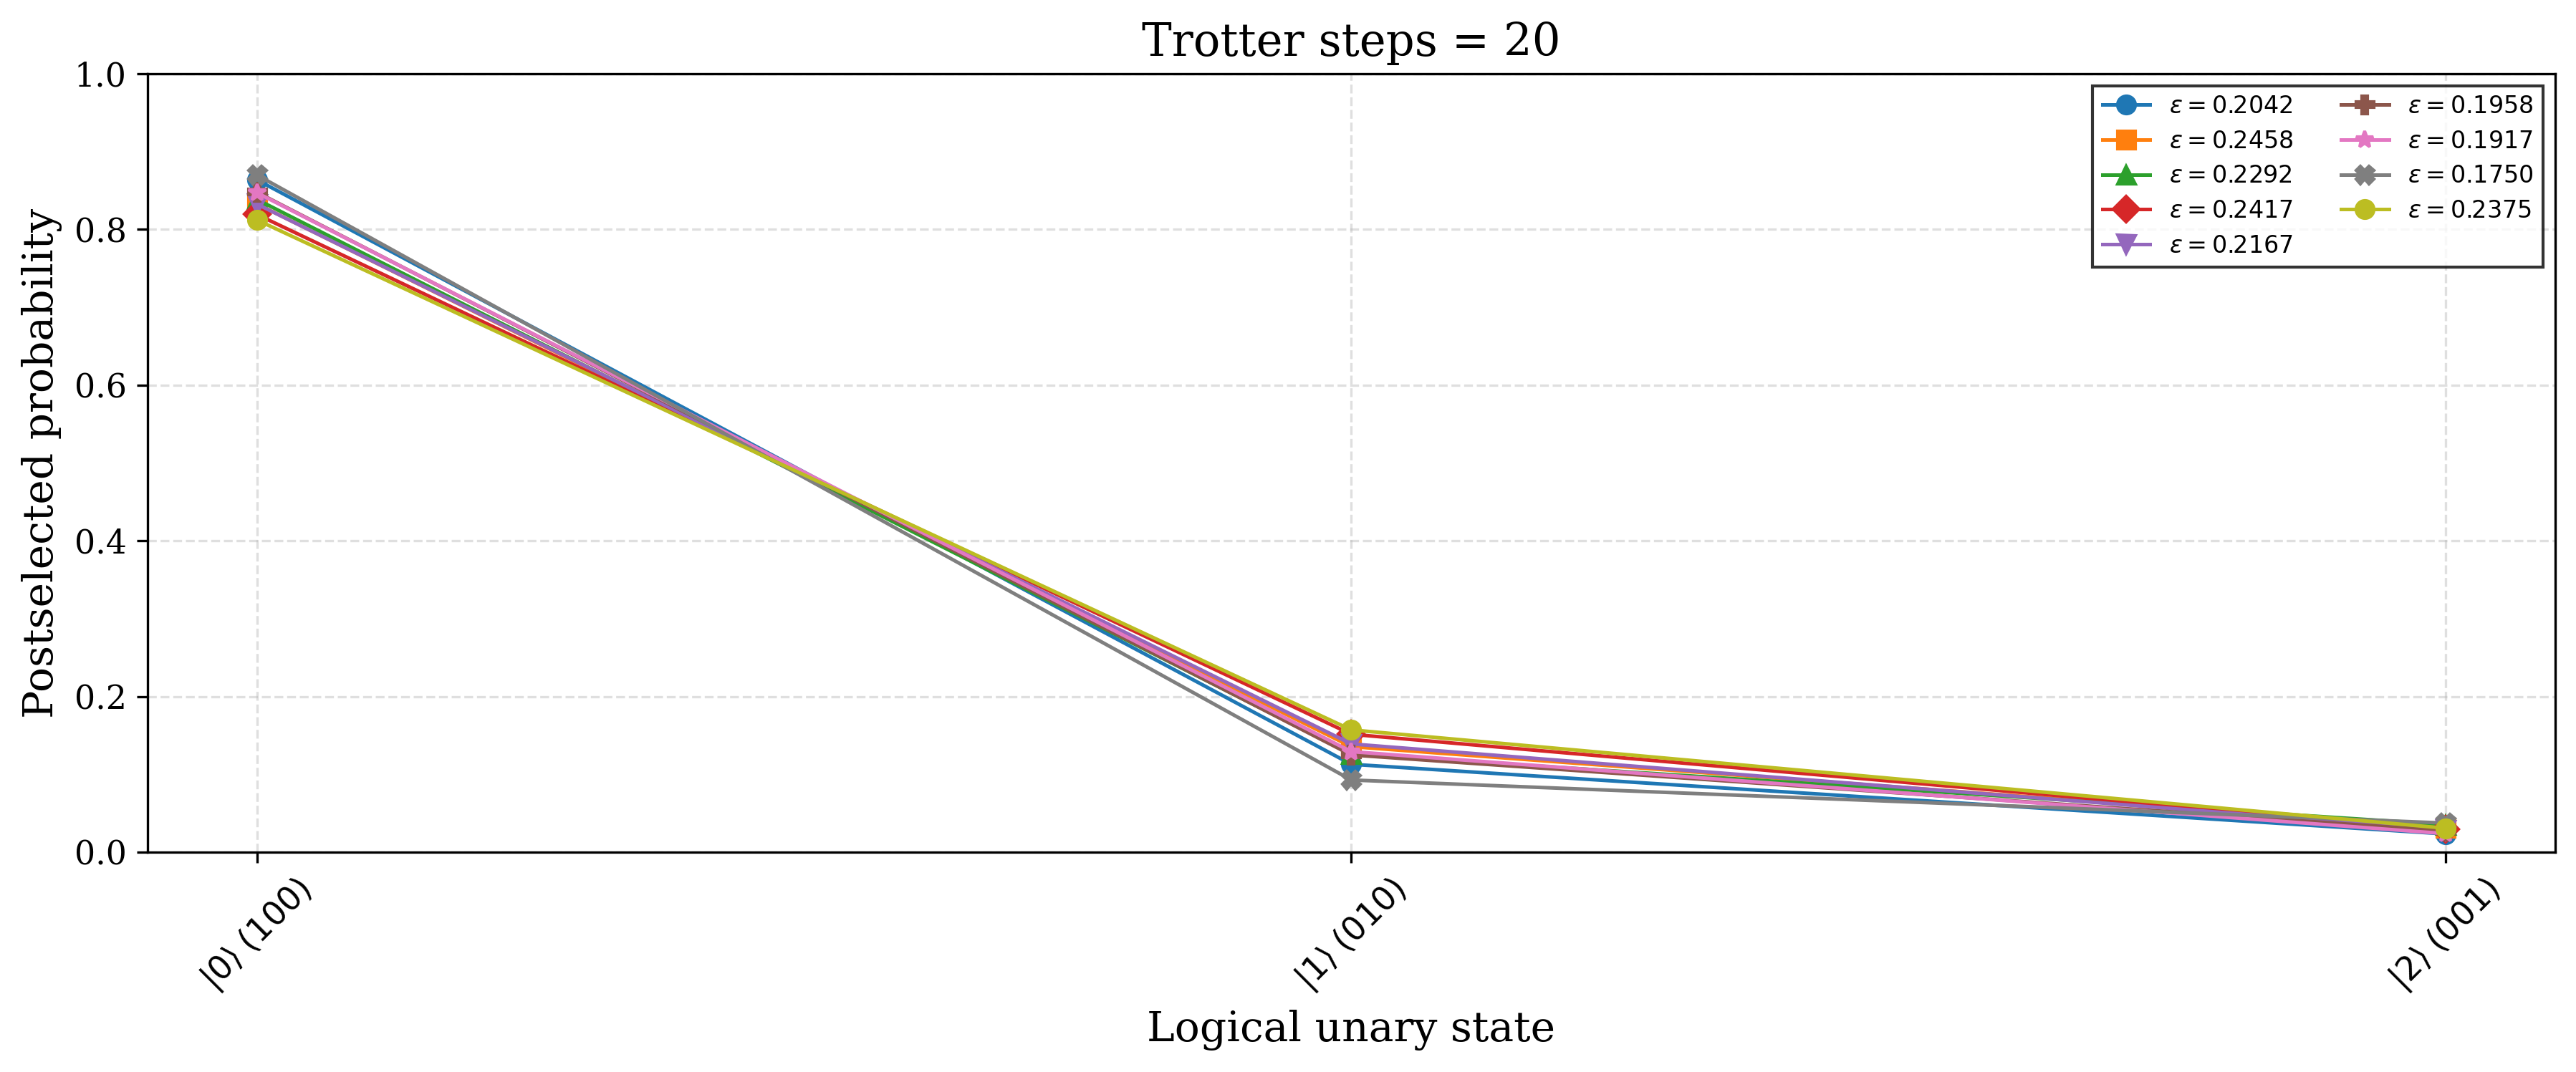

In [15]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 8,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.2,
    "lines.markersize": 6,
    "figure.dpi": 300,
})

states = ['100', '010', '001']
logical_labels = [
    r'$|0\rangle\;(100)$',
    r'$|1\rangle\;(010)$',
    r'$|2\rangle\;(001)$'
    ]
steps_value = troter_steps[0]

selected_eps = [eps for eps, F in high_fidelity_eps]

fig, ax = plt.subplots(figsize=(12, 5))

markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']

for i, eps in enumerate(selected_eps):

    probs = postselected_results[steps_value][eps]
    x = np.arange(len(states)) 
    y = [probs.get(state, 0) for state in states]


    ax.plot(
        x,
        y,
        marker=markers[i % len(markers)],
        label=rf'$\epsilon={eps:.4f}$'
    )

ax.set_xlabel("Logical unary state")
ax.set_ylabel("Postselected probability")
ax.set_title(f"Trotter steps = {steps_value}")
ax.set_xticks(x)
ax.set_xticklabels(logical_labels)
ax.set_ylim(0,1)

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor='black',
    ncol=2
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/state_distribution0.pdf",
    bbox_inches="tight"
)

plt.show()

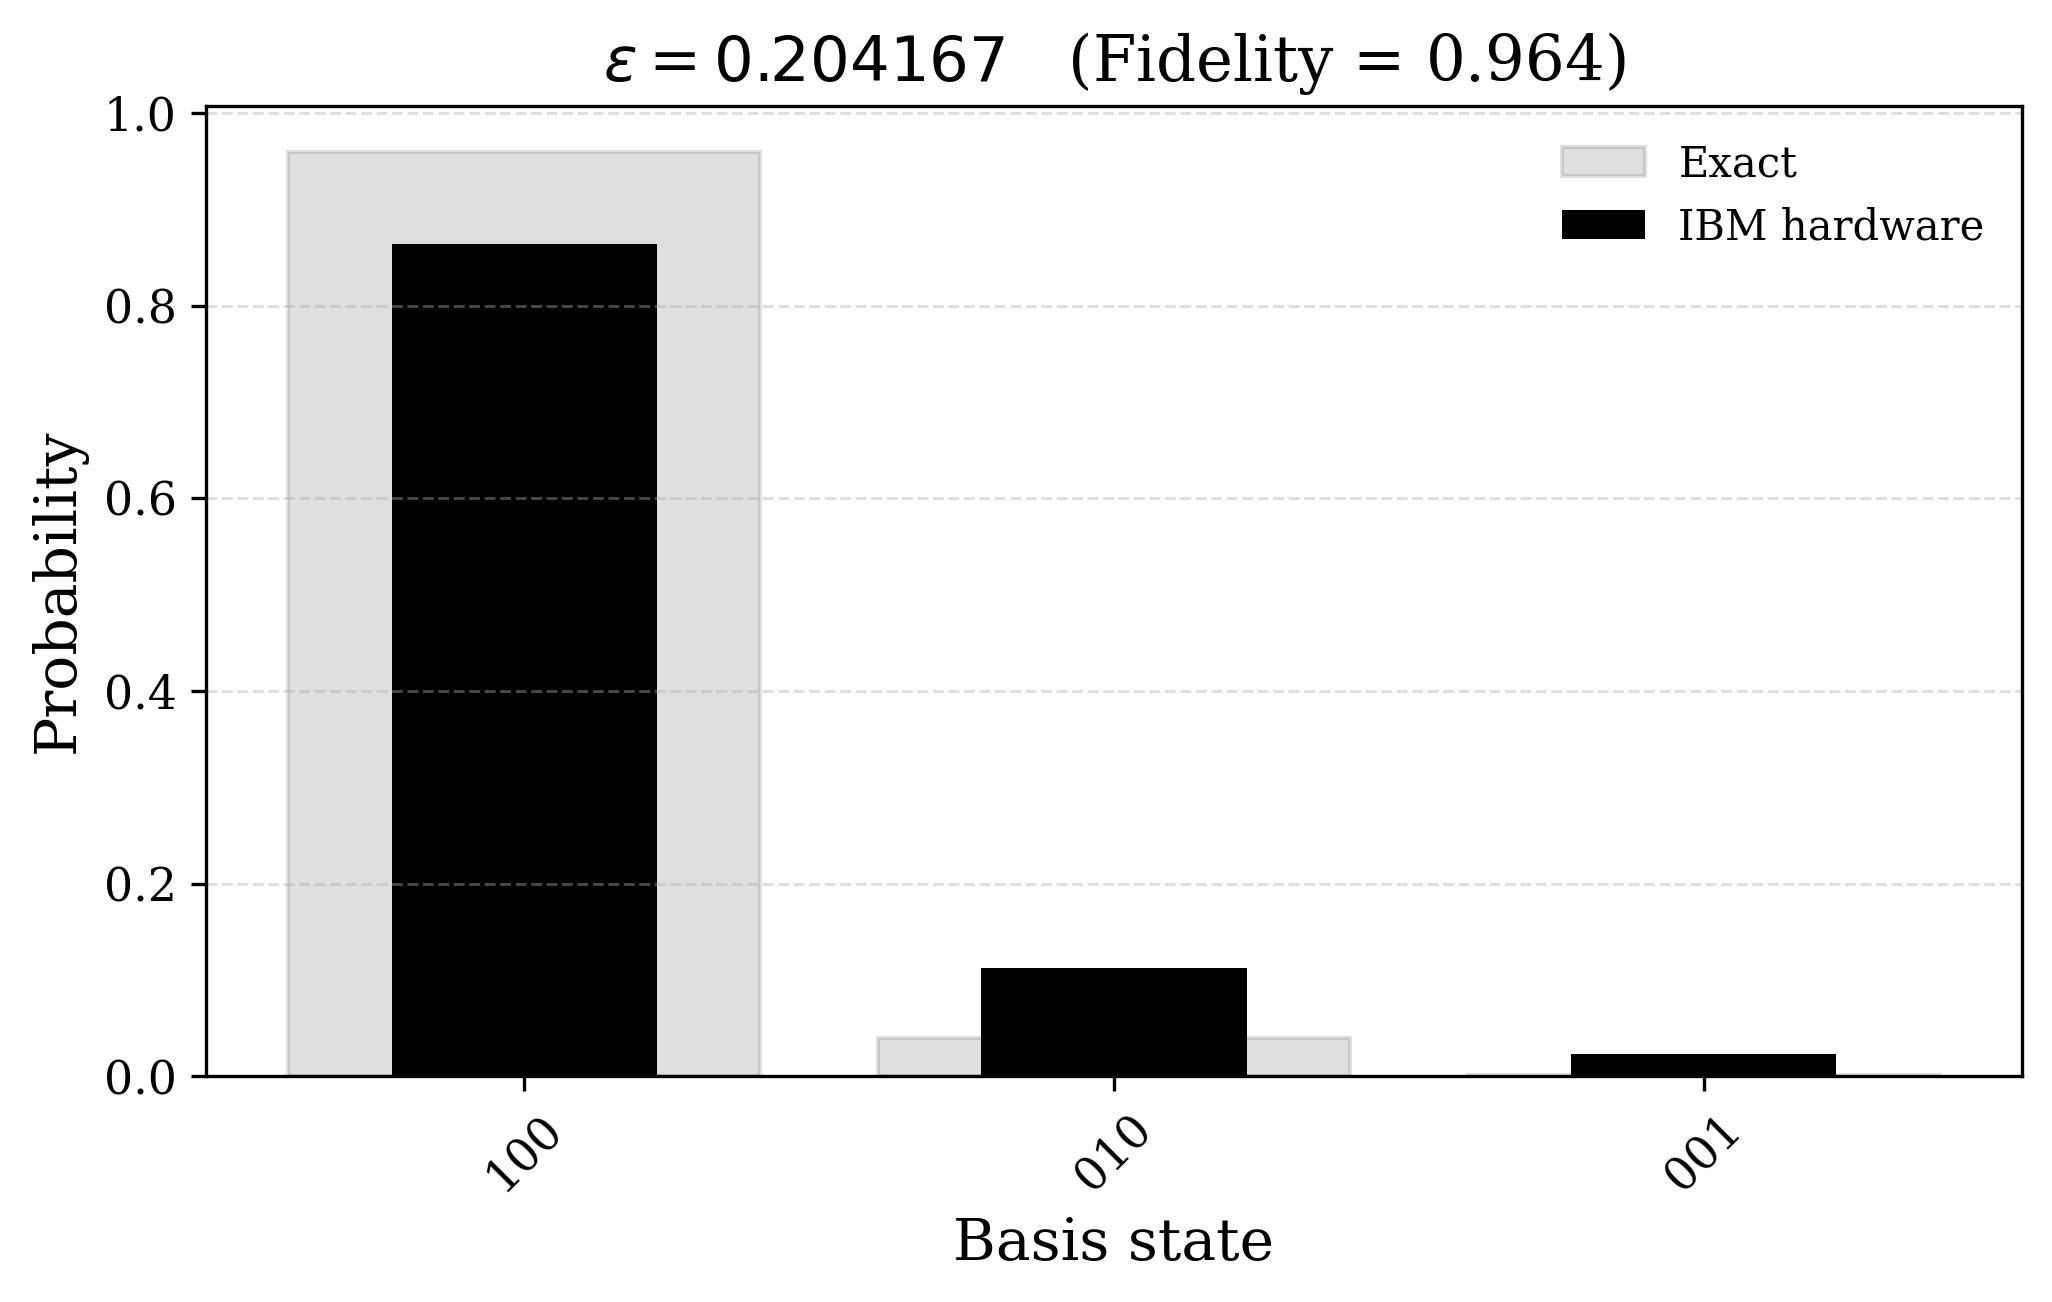

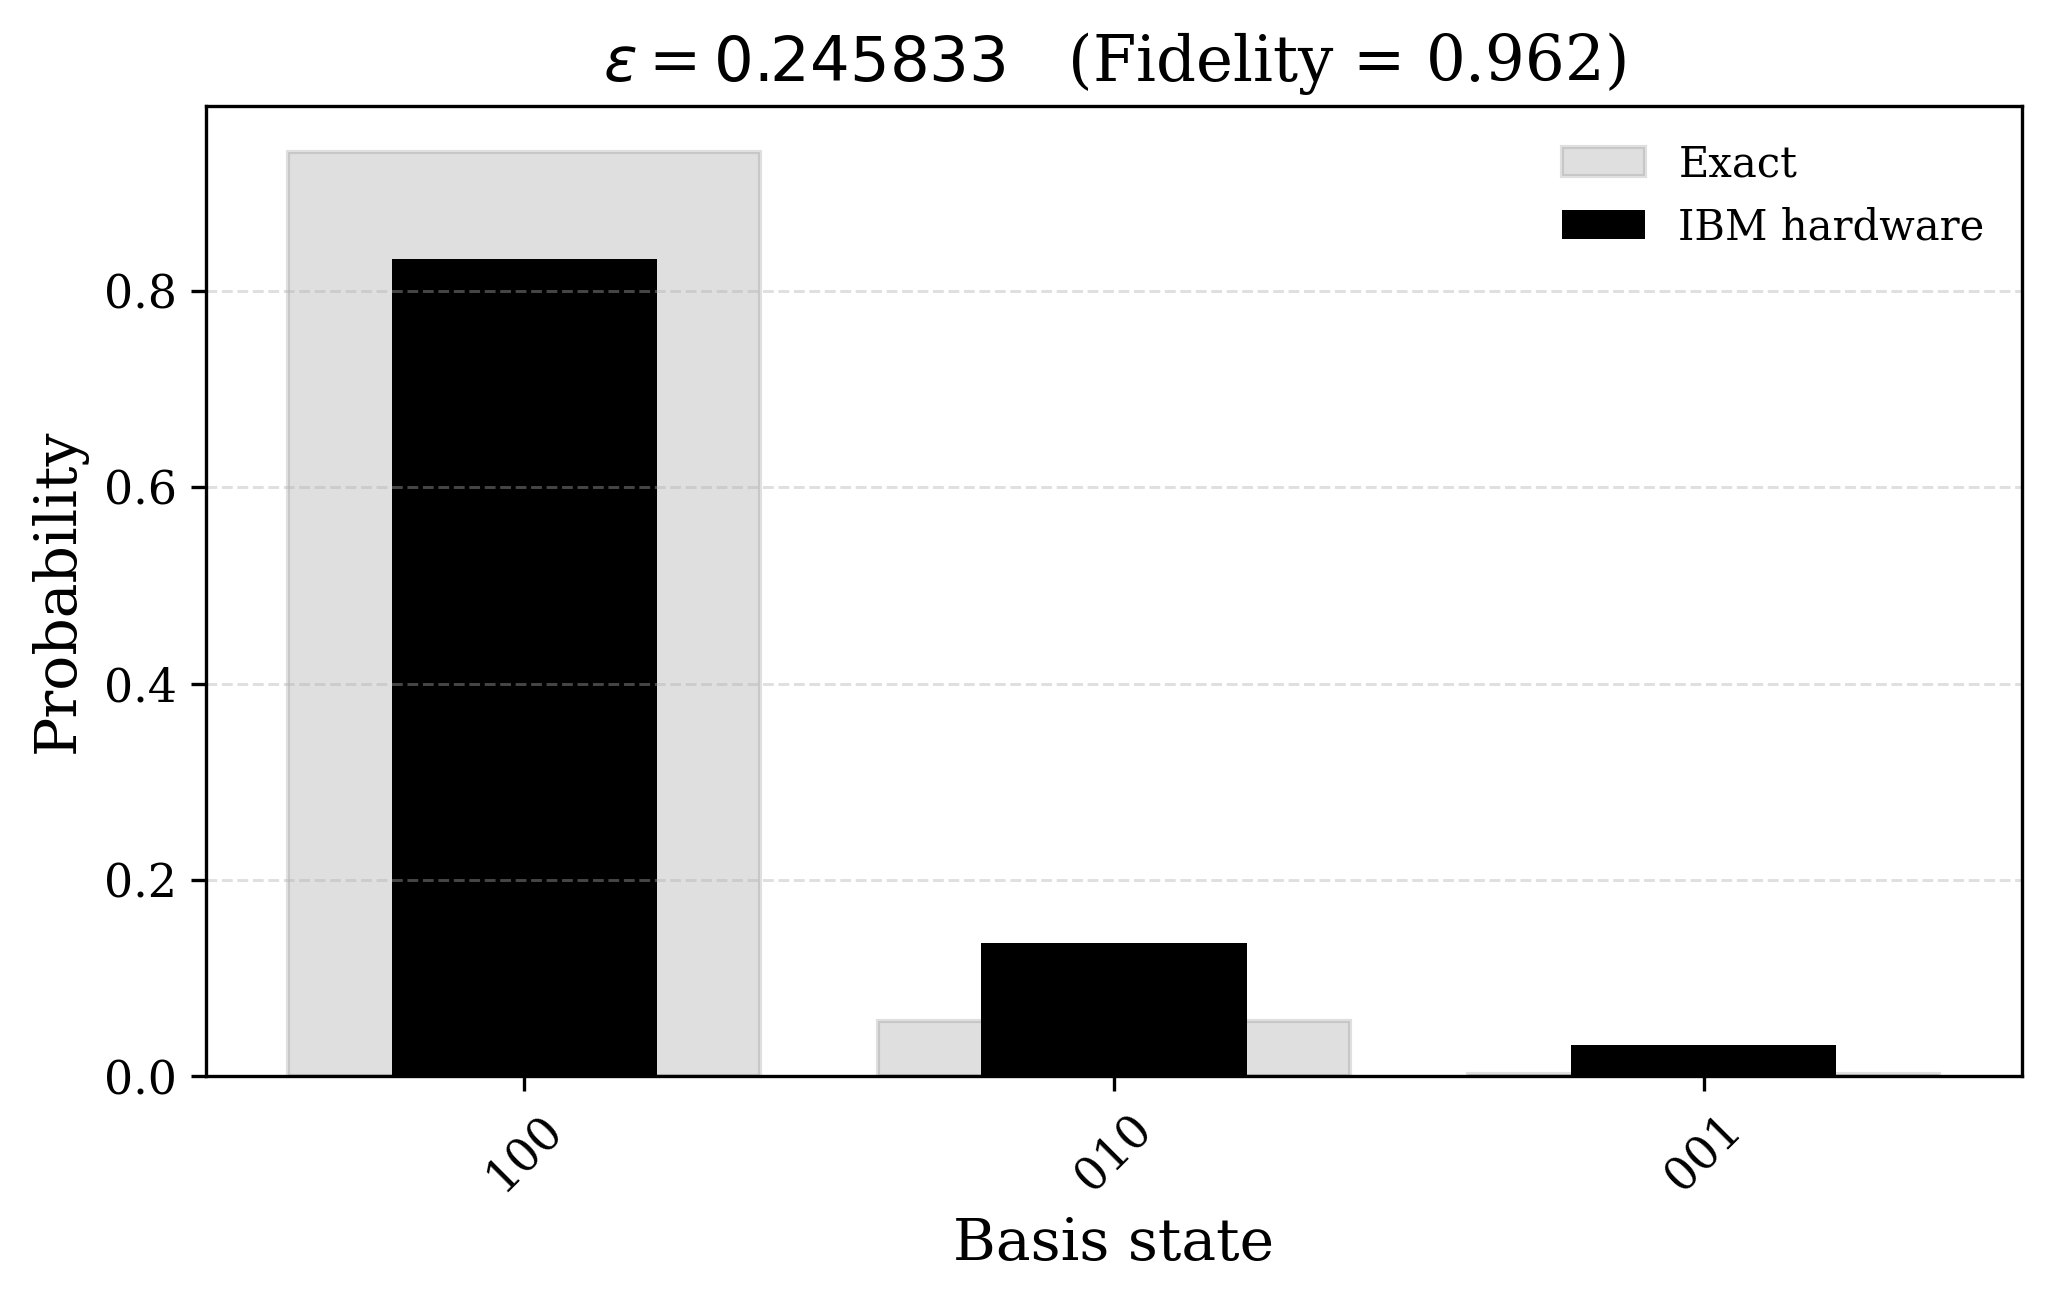

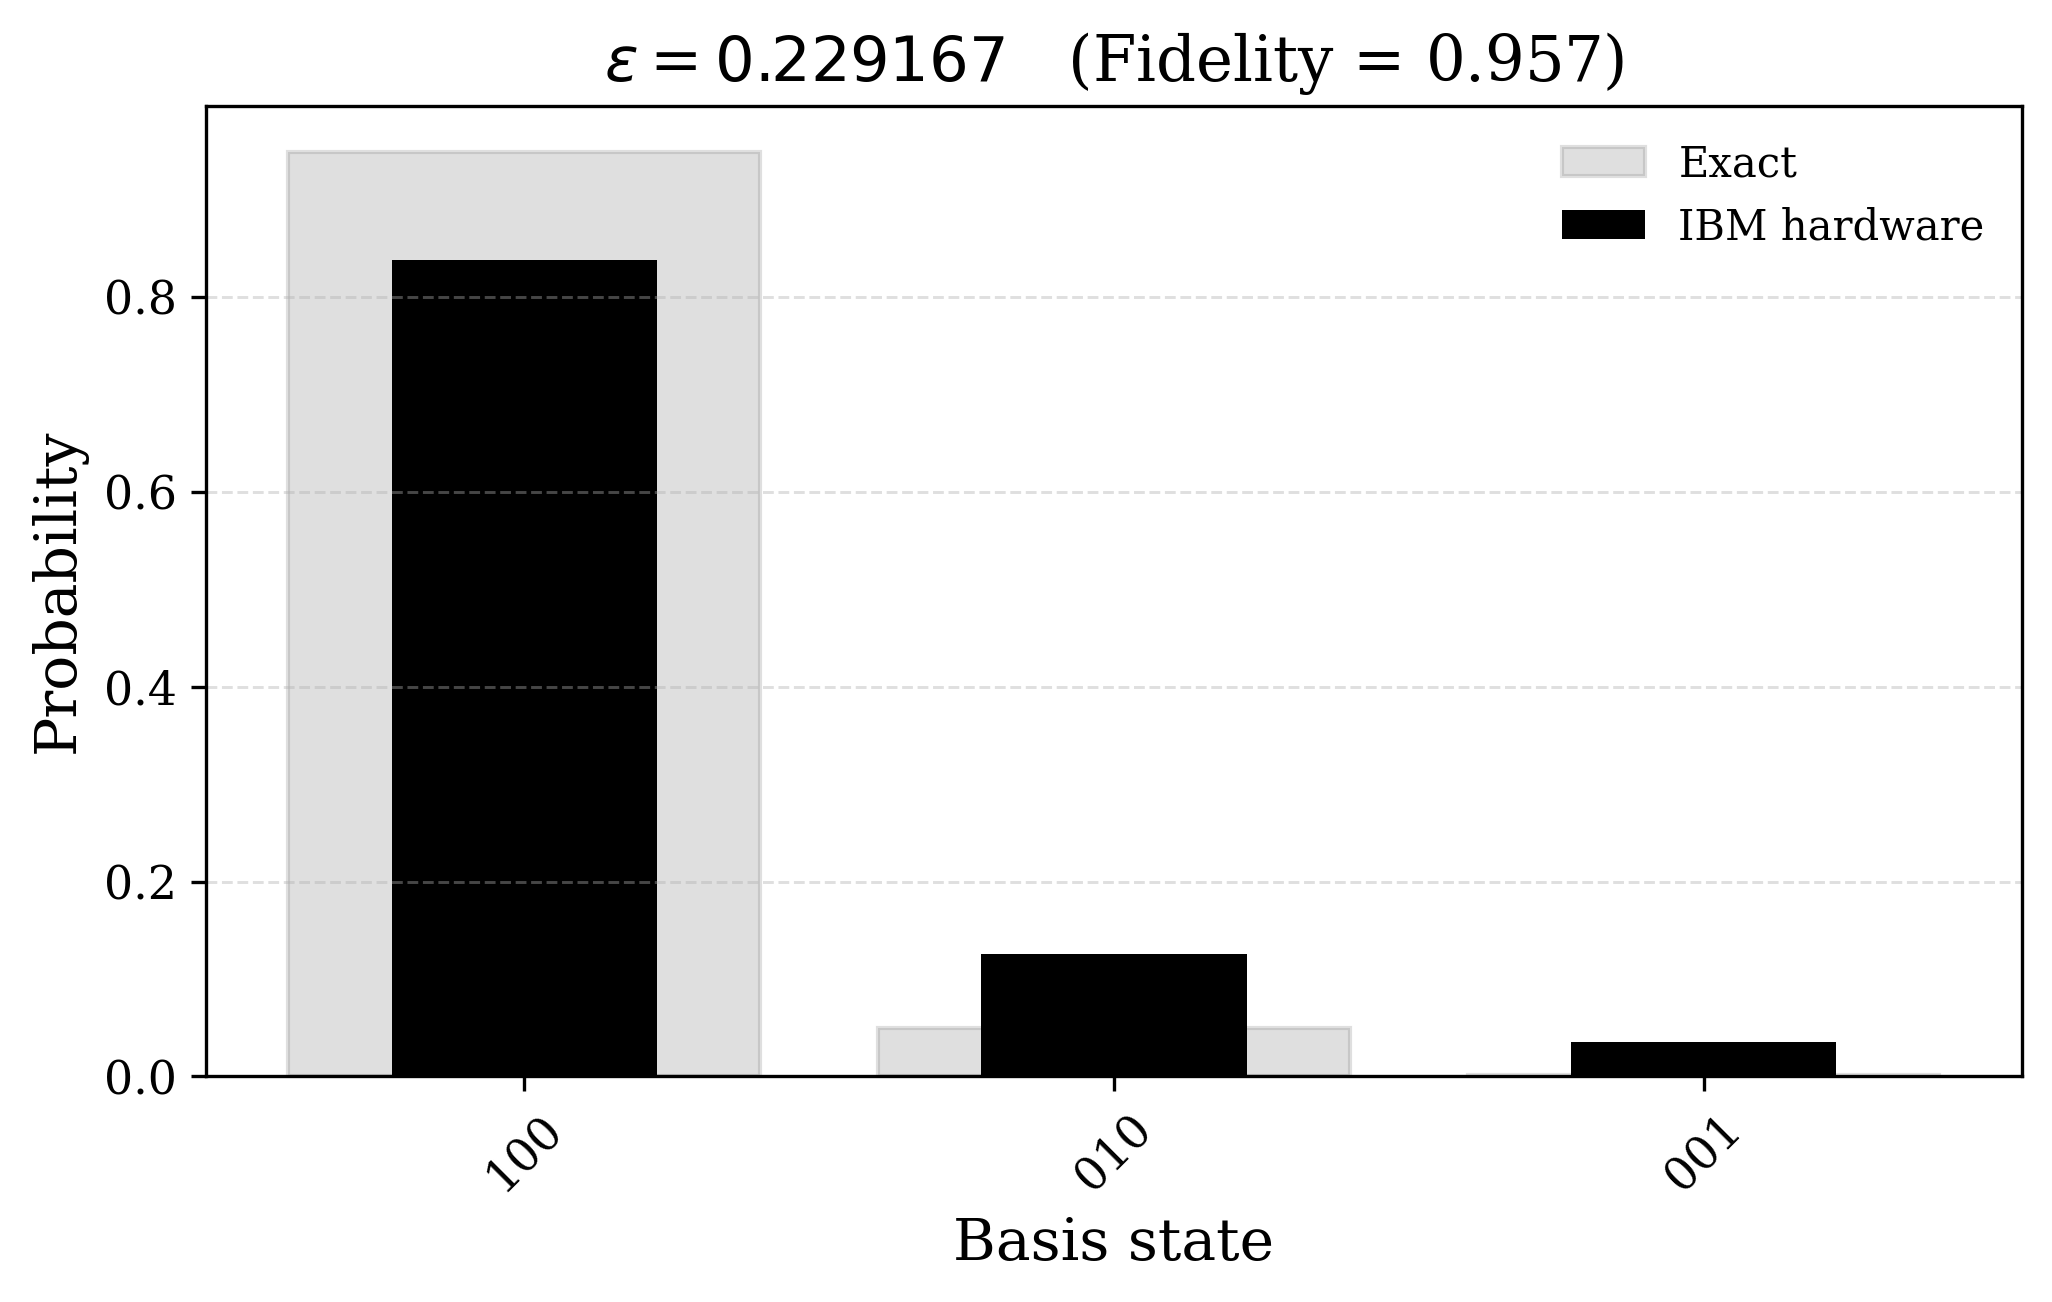

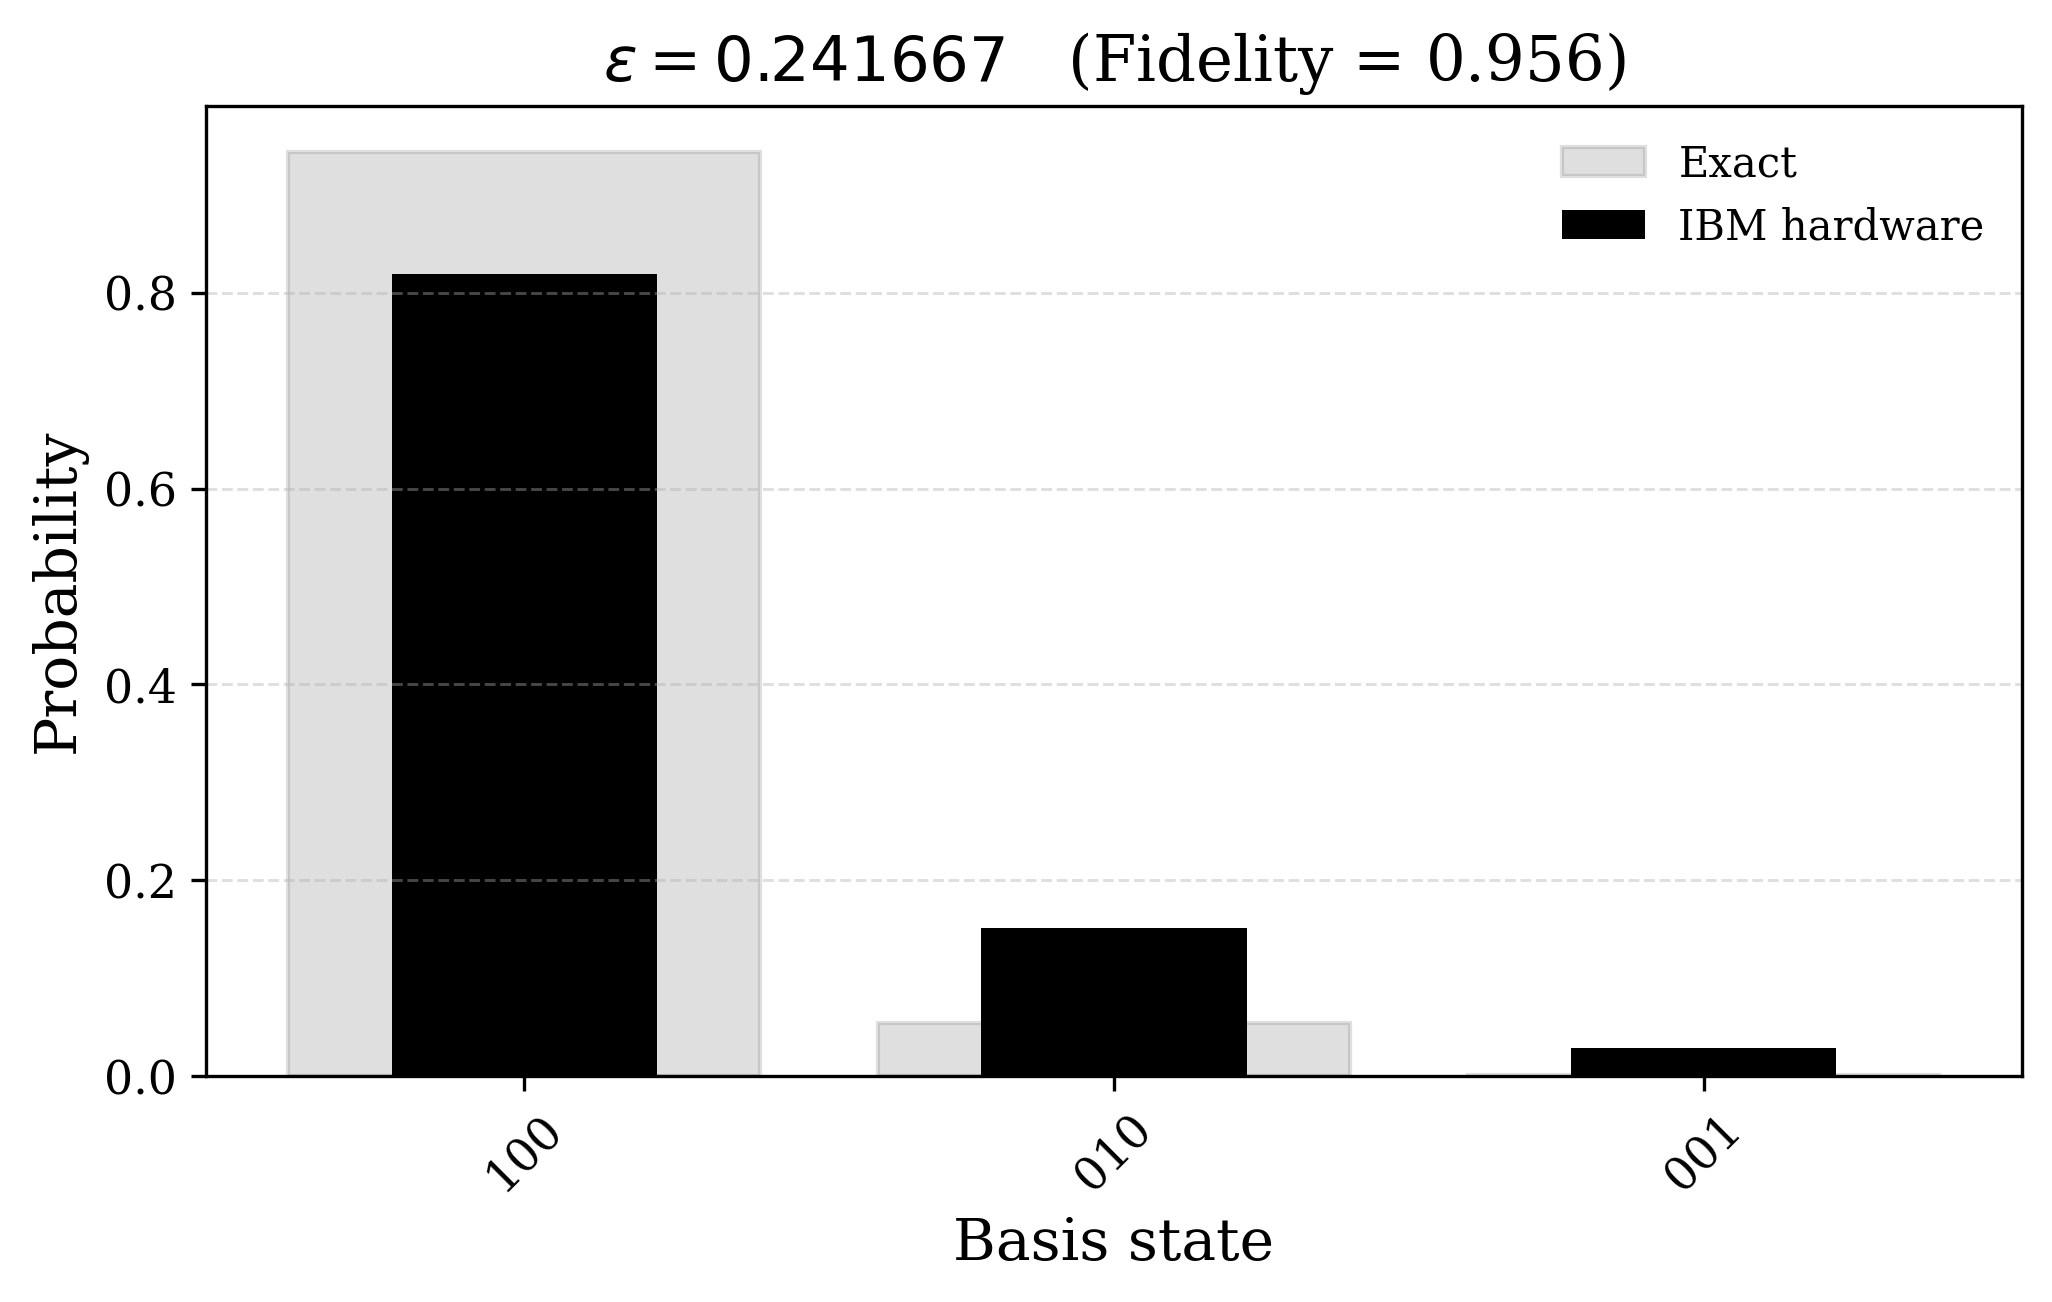

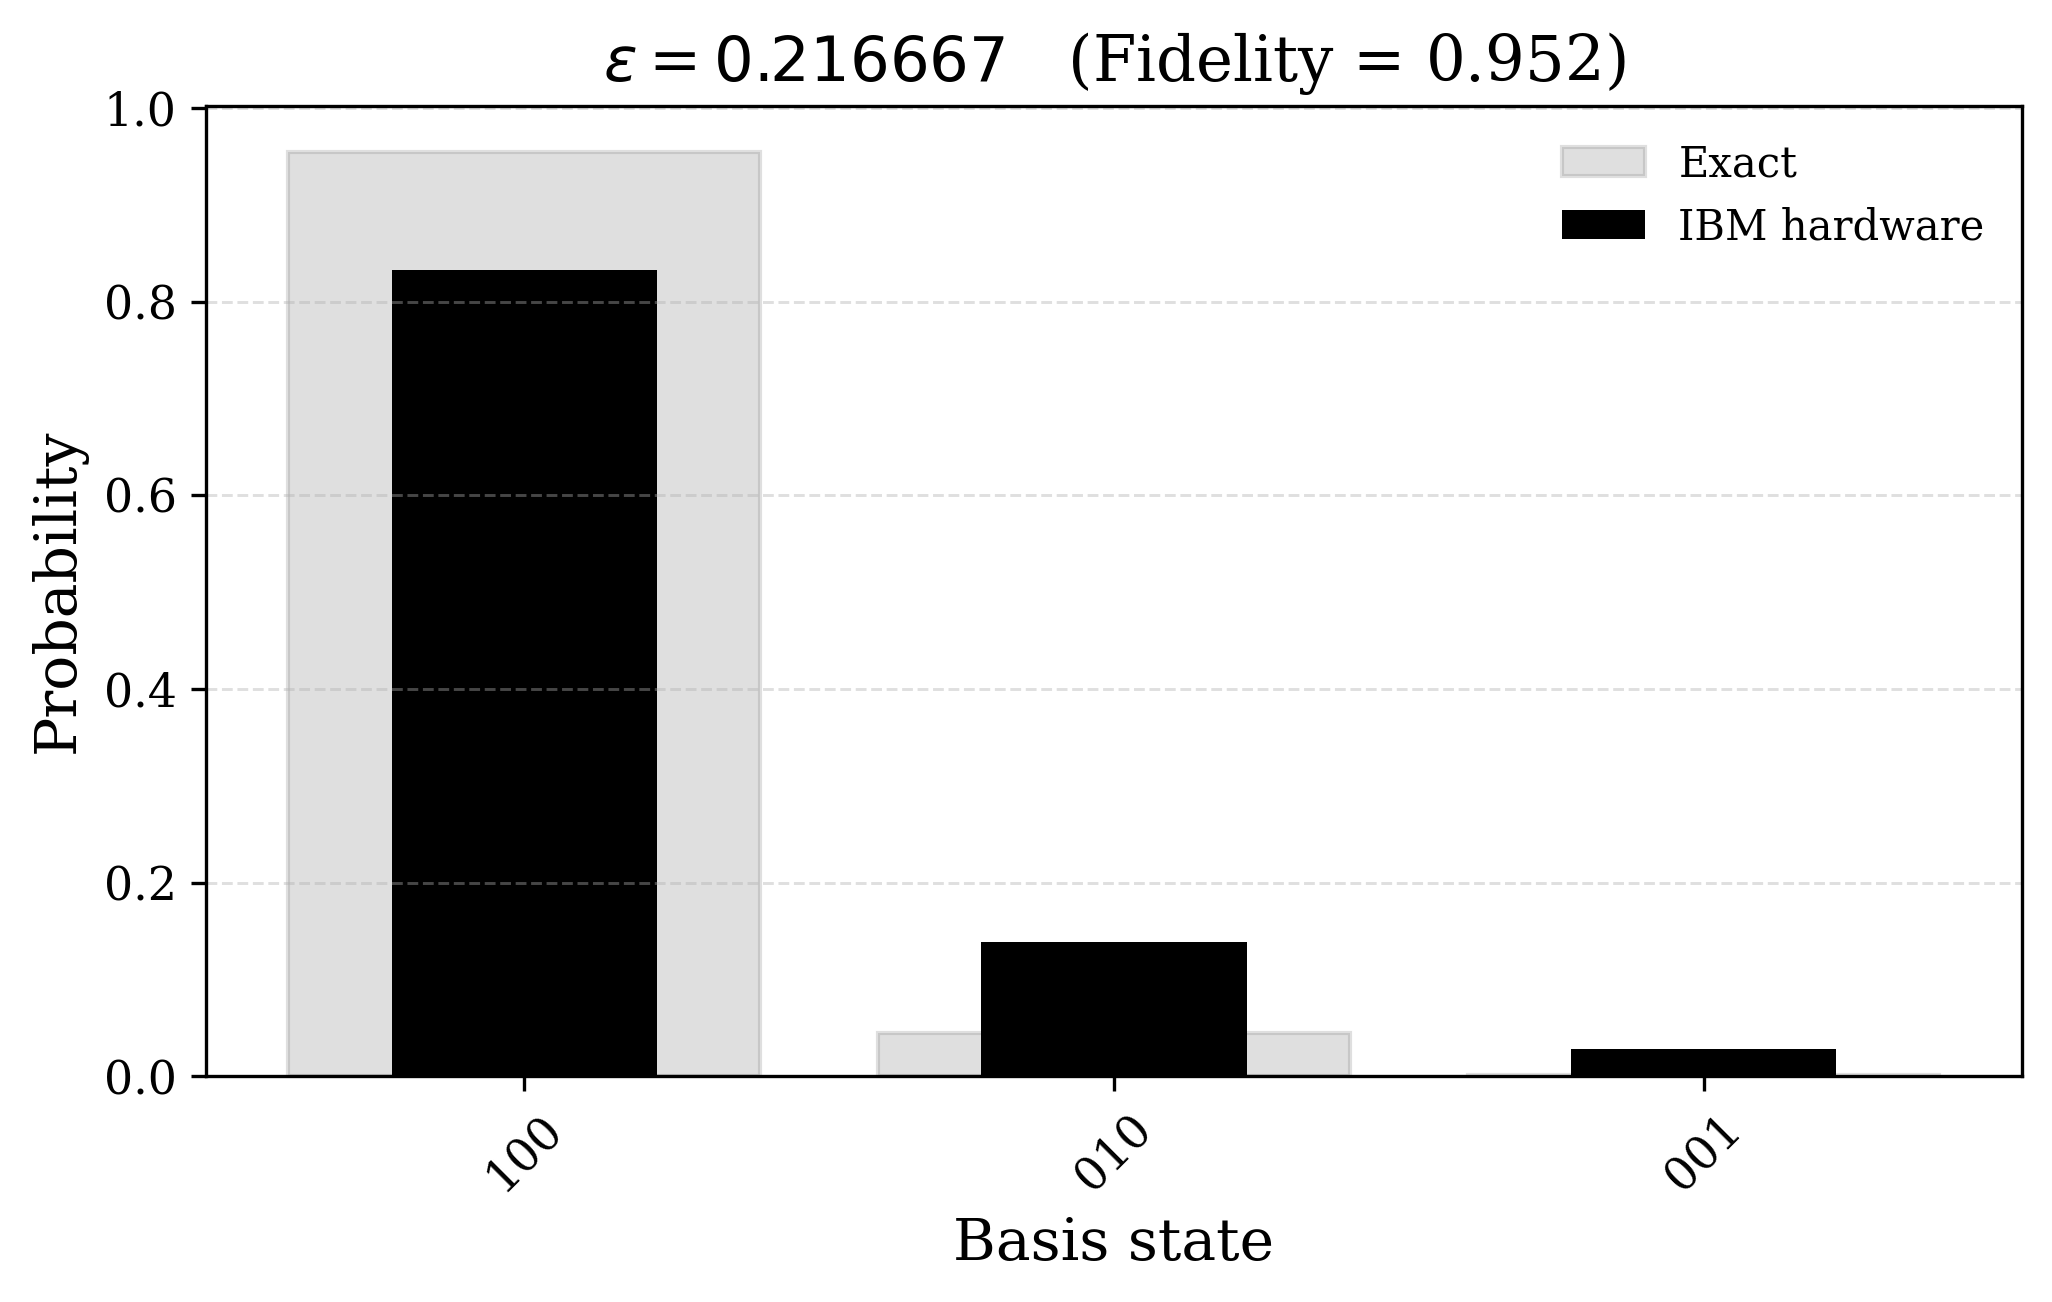

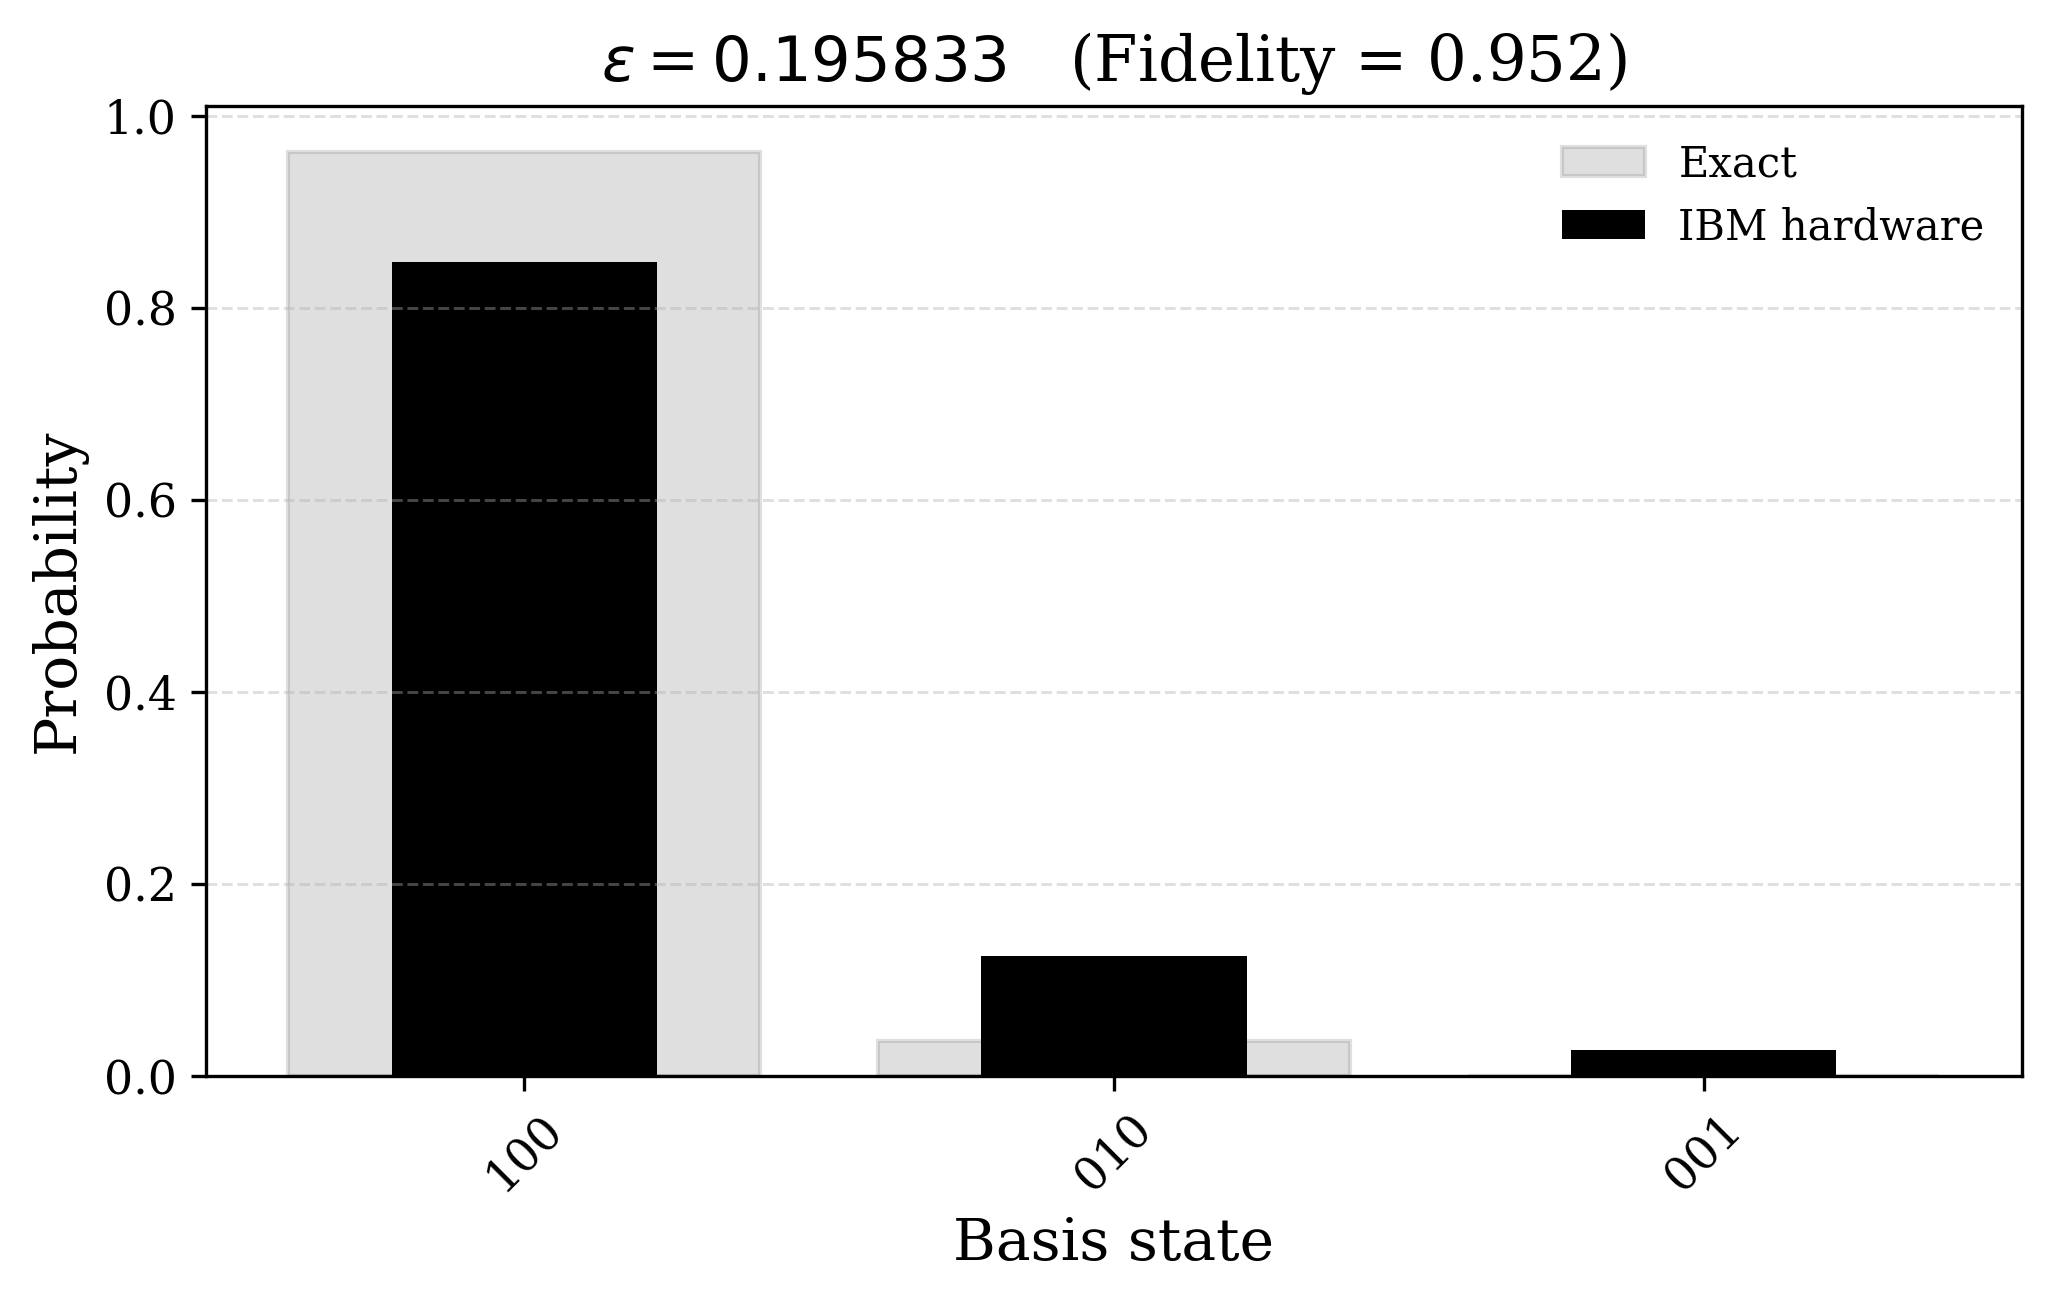

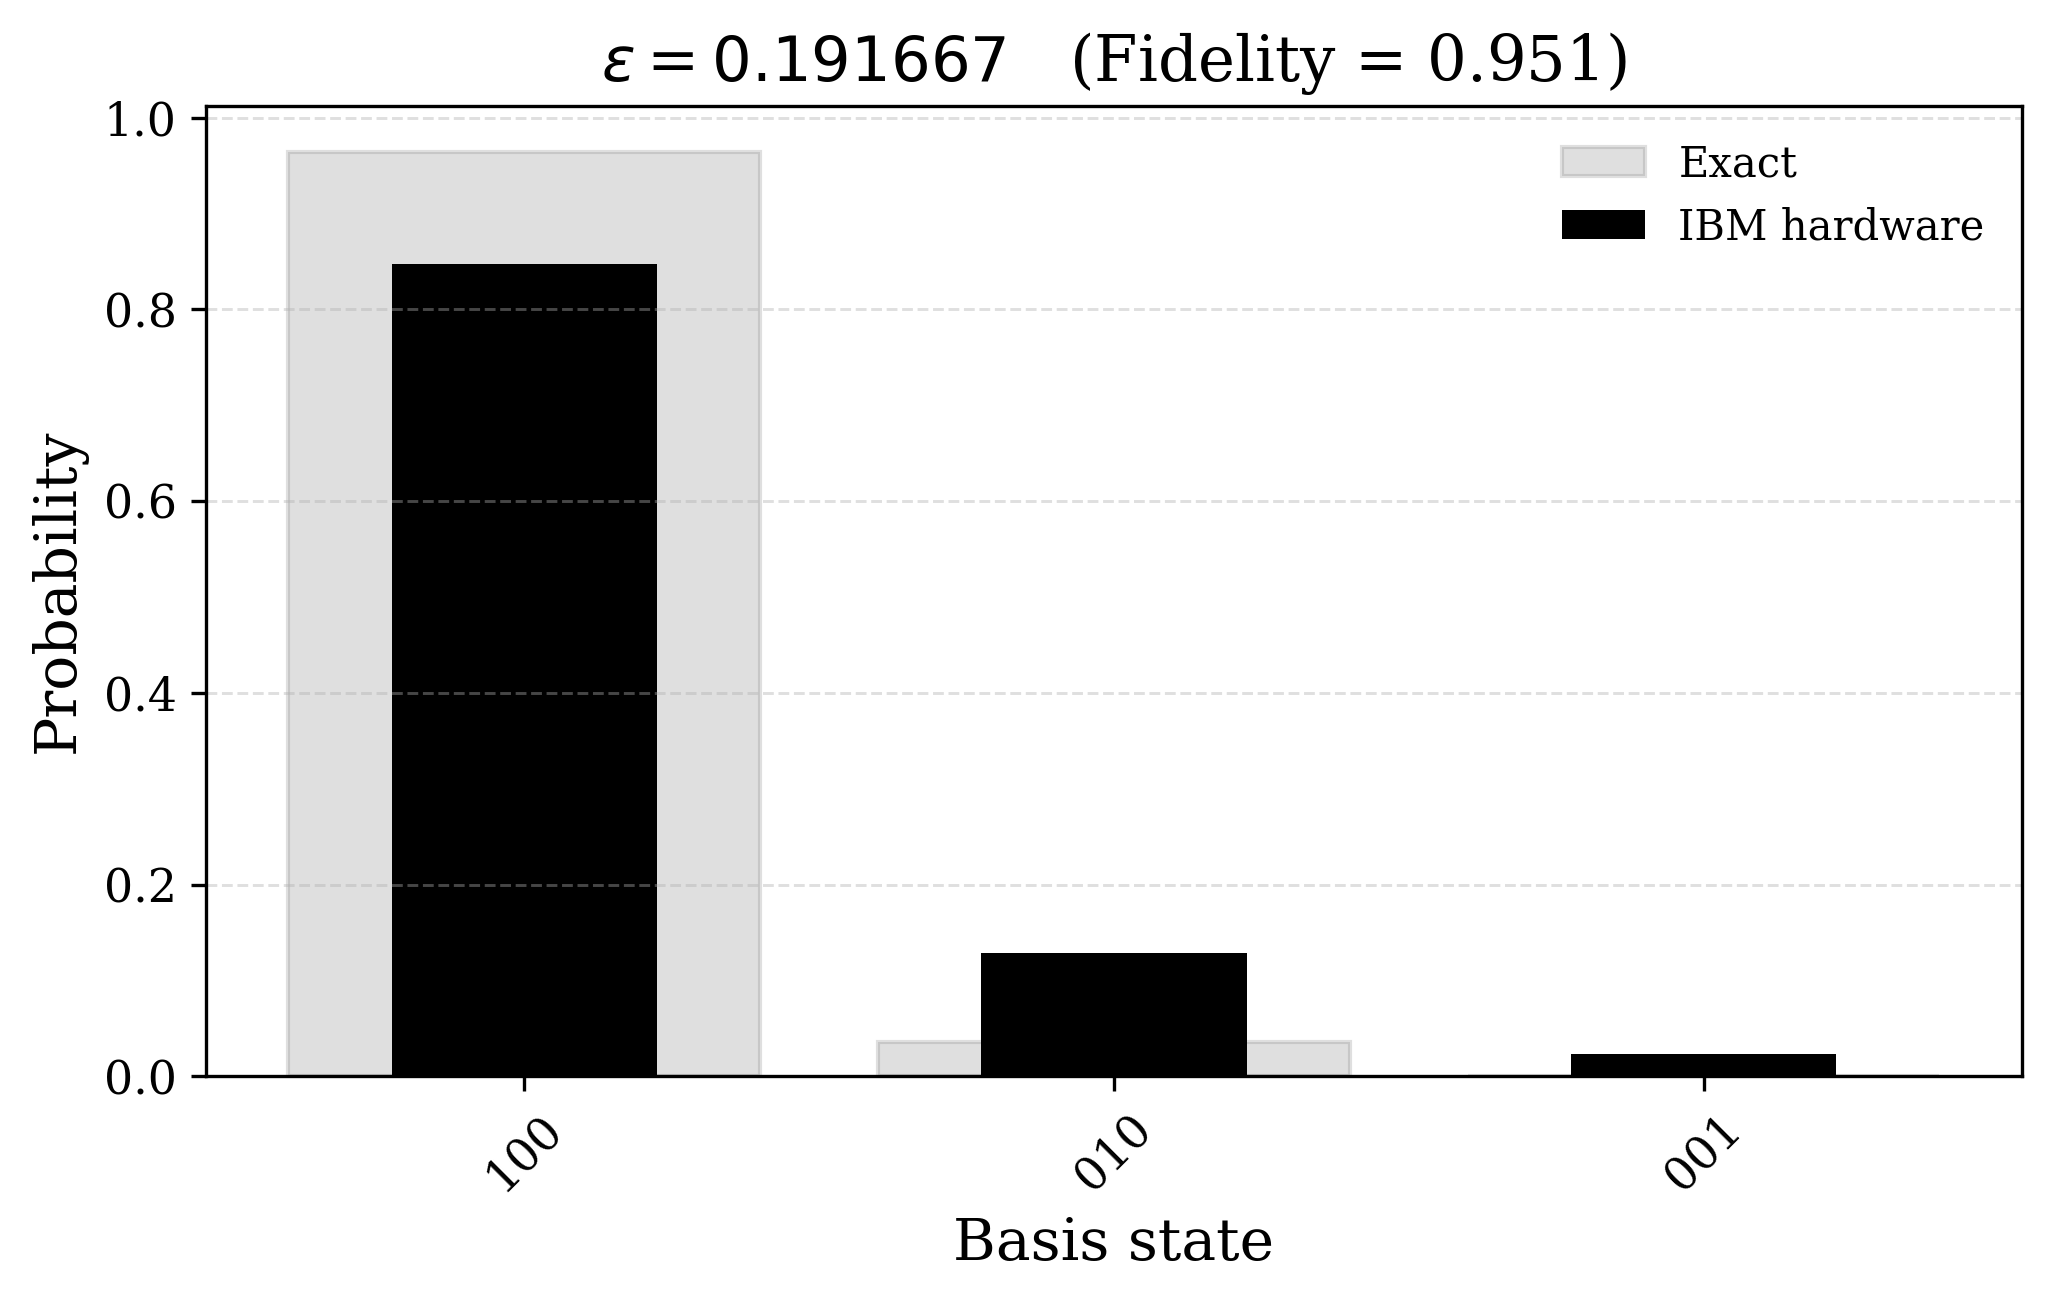

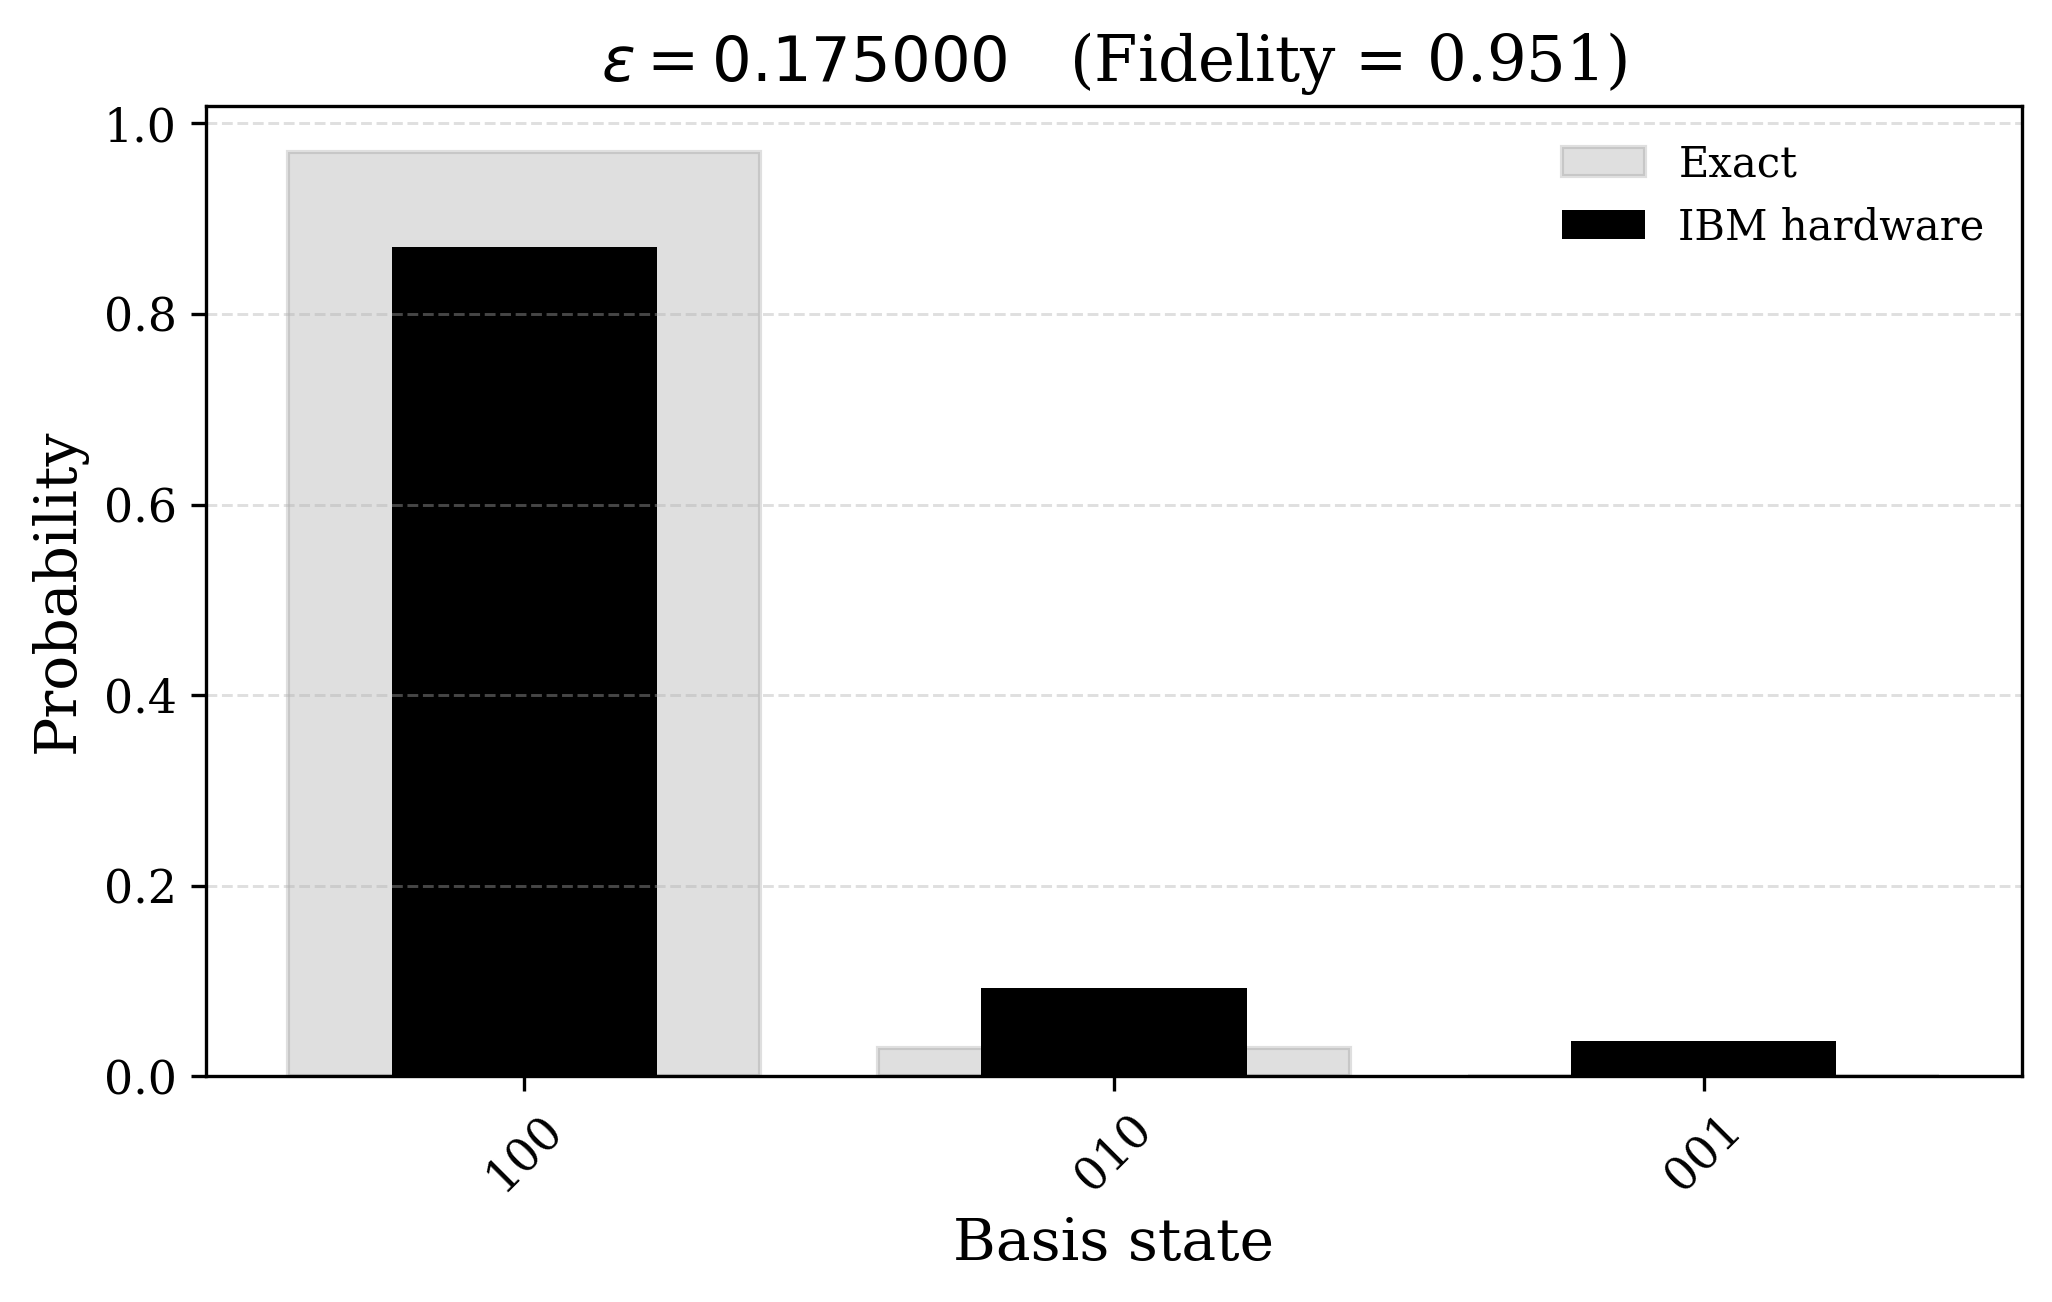

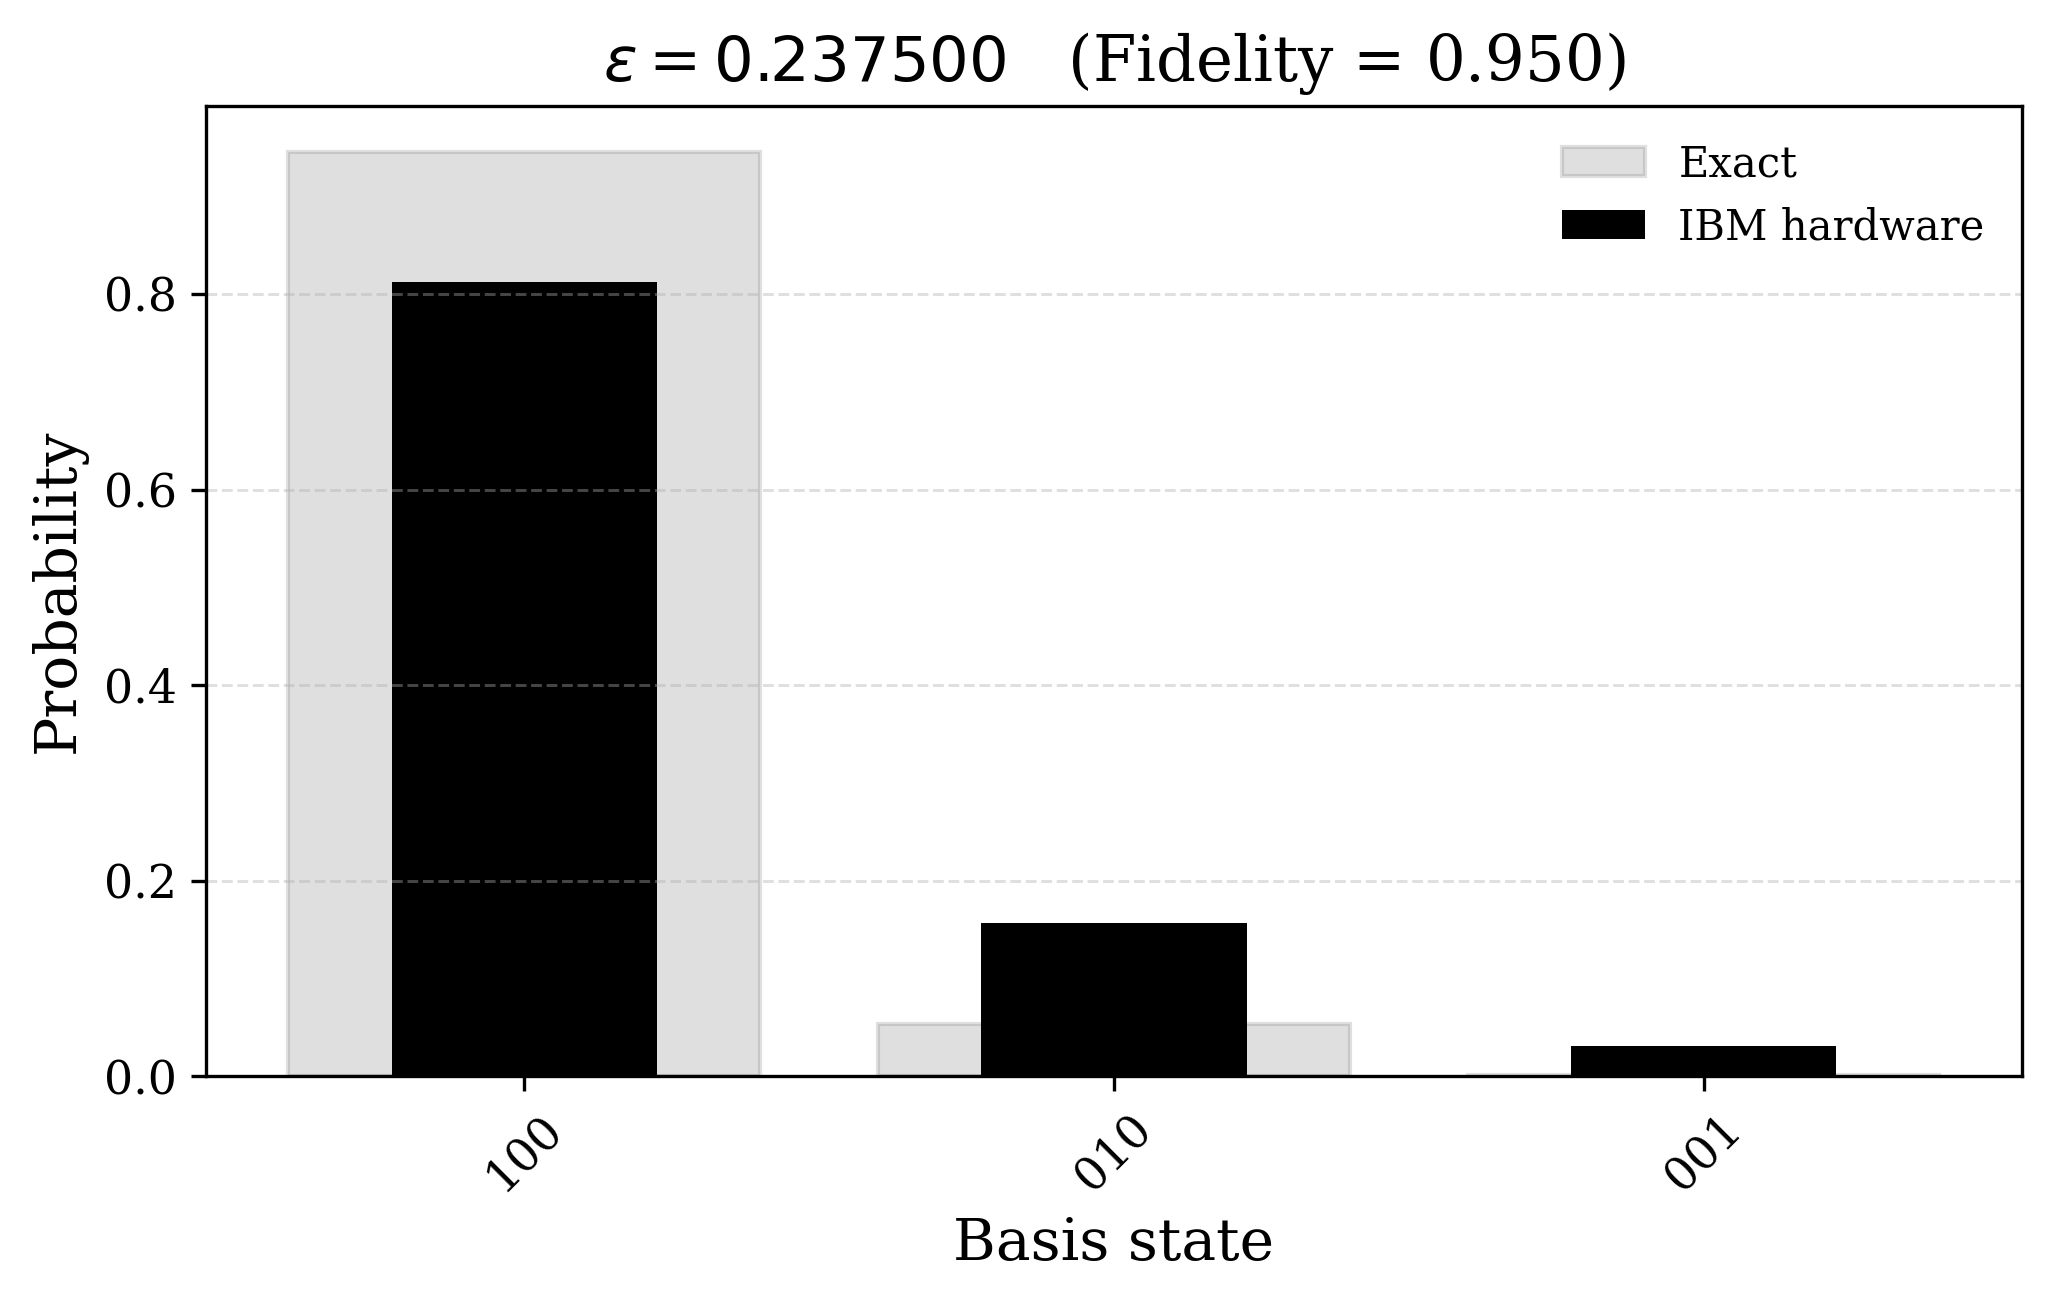

In [23]:
steps_value = troter_steps[0]

selected_eps = [eps for eps, F in high_fidelity_eps]

states = ['100', '010', '001']

for eps in selected_eps:

    # ==================================================
    # Hardware probabilities (postselected)
    # ==================================================
    exp_probs = [
        postselected_results[steps_value][eps].get(state, 0)
        for state in states
    ]

    # ==================================================
    # Exact probabilities restricted to allowed states
    # ==================================================
    exact_probs = true_probs[steps_value][eps]

    restricted_true = {
        state: exact_probs.get(state, 0)
        for state in states
    }

    norm = sum(restricted_true.values())

    true_probs_post = [
        restricted_true[state] / norm
        if norm > 0 else 0
        for state in states
    ]

    # ==================================================
    # Plot
    # ==================================================
    x = np.arange(len(states))

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Exact
    ax.bar(
        x,
        true_probs_post,
        width=0.80,
        alpha=0.25,
        color='gray',
        edgecolor='gray',
        label='Exact'
    )

    # Hardware
    ax.bar(
        x,
        exp_probs,
        width=0.45,
        color='black',
        label='IBM hardware'
    )

    fidelity = fidelity_results[steps_value][eps]

    ax.set_xticks(x)
    ax.set_xticklabels(states, rotation=45)

    ax.set_xlabel("Basis state")
    ax.set_ylabel("Probability")

    ax.set_title(
        rf'$\epsilon={eps:.6f}$   (Fidelity = {fidelity:.3f})'
    )

    ax.legend(frameon=False)

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.7,
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        f"plots/distribution_eps_{eps:.6f}.pdf",
        bbox_inches="tight"
    )

    plt.show()

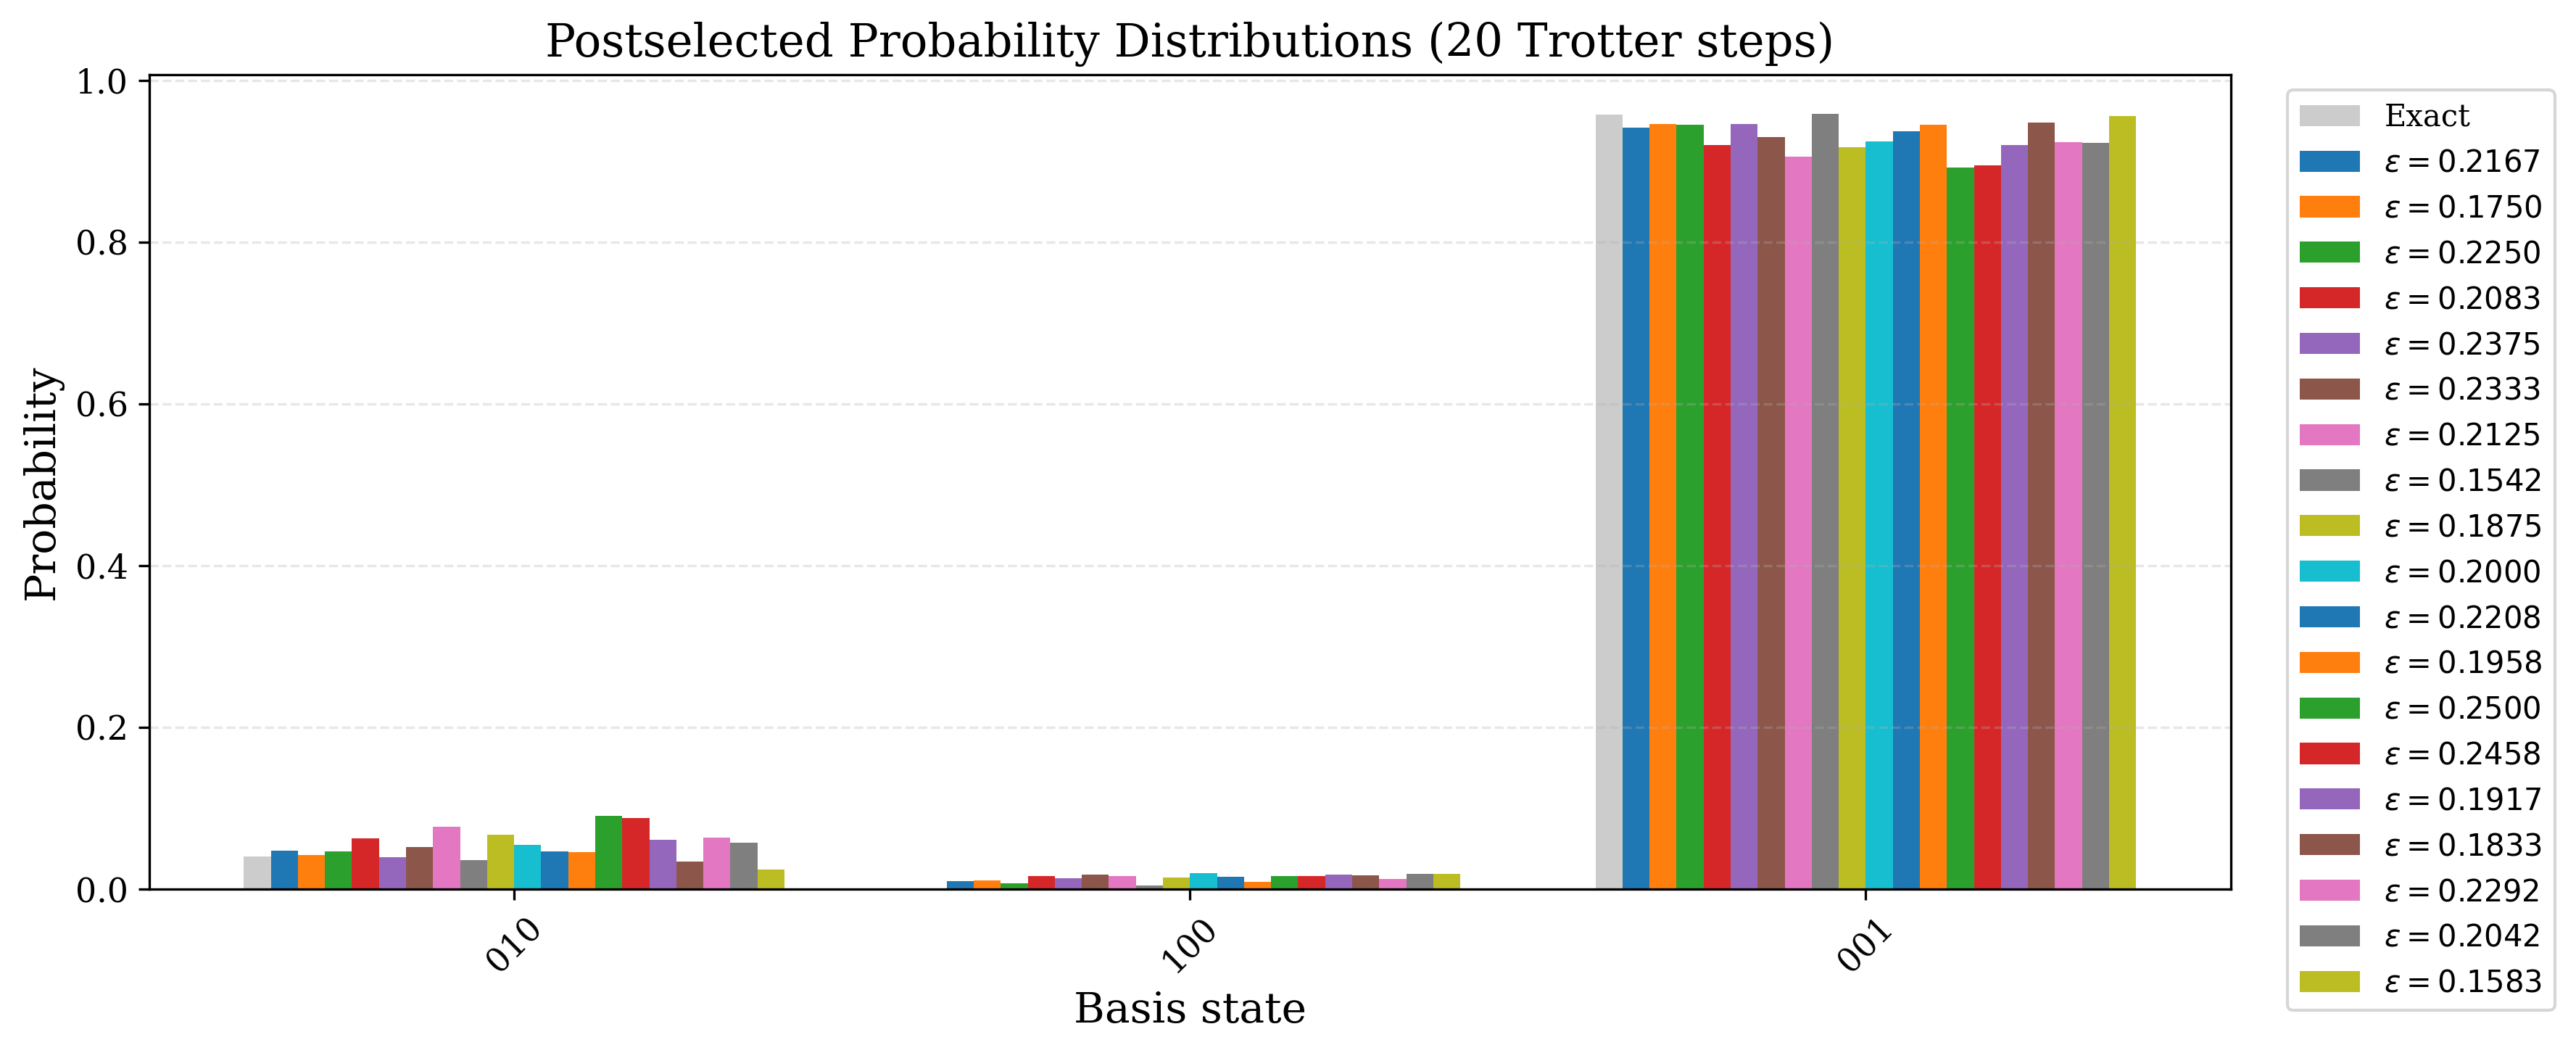

In [12]:
steps_value = troter_steps[0]

selected_eps = [eps for eps, F in high_fidelity_eps]

n_states = len(allowed)
n_eps = len(selected_eps)

# =====================================
# Exact distribution
# =====================================
eps_ref = selected_eps[0]

exact_probs = true_probs[steps_value][eps_ref]

restricted_true = {
    state: exact_probs.get(state, 0)
    for state in allowed
}

norm = sum(restricted_true.values())

true_probs_post = np.array([
    restricted_true[state] / norm
    for state in allowed
])

# =====================================
# Figure
# =====================================
fig, ax = plt.subplots(figsize=(12,5))

x = np.arange(n_states)

# width of each individual bar
bar_width = 0.8 / (n_eps + 1)

# -------------------------------------
# Exact bars
# -------------------------------------
ax.bar(
    x - 0.4 + bar_width/2,
    true_probs_post,
    width=bar_width,
    alpha=0.4,
    color='gray',
    label='Exact'
)

# -------------------------------------
# Hardware bars
# -------------------------------------
for i, eps in enumerate(selected_eps):

    exp_counts = results[steps_value][eps]

    allowed_counts = {
        state: exp_counts.get(state, 0)
        for state in allowed
    }

    total = sum(allowed_counts.values())

    exp_probs = np.array([
        allowed_counts[state]/total
        if total > 0 else 0
        for state in allowed
    ])

    offset = -0.4 + (i+1.5)*bar_width

    ax.bar(
        x + offset,
        exp_probs,
        width=bar_width,
        label=rf'$\epsilon={eps:.4f}$'
    )

ax.set_xticks(x)
ax.set_xticklabels(allowed, rotation=45)

ax.set_xlabel("Basis state")
ax.set_ylabel("Probability")

ax.set_title(
    f"Postselected Probability Distributions ({steps_value} Trotter steps)"
)

ax.legend(
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig("plots/combined_distribution.pdf", bbox_inches="tight")
plt.savefig("plots/combined_distribution.png", dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()

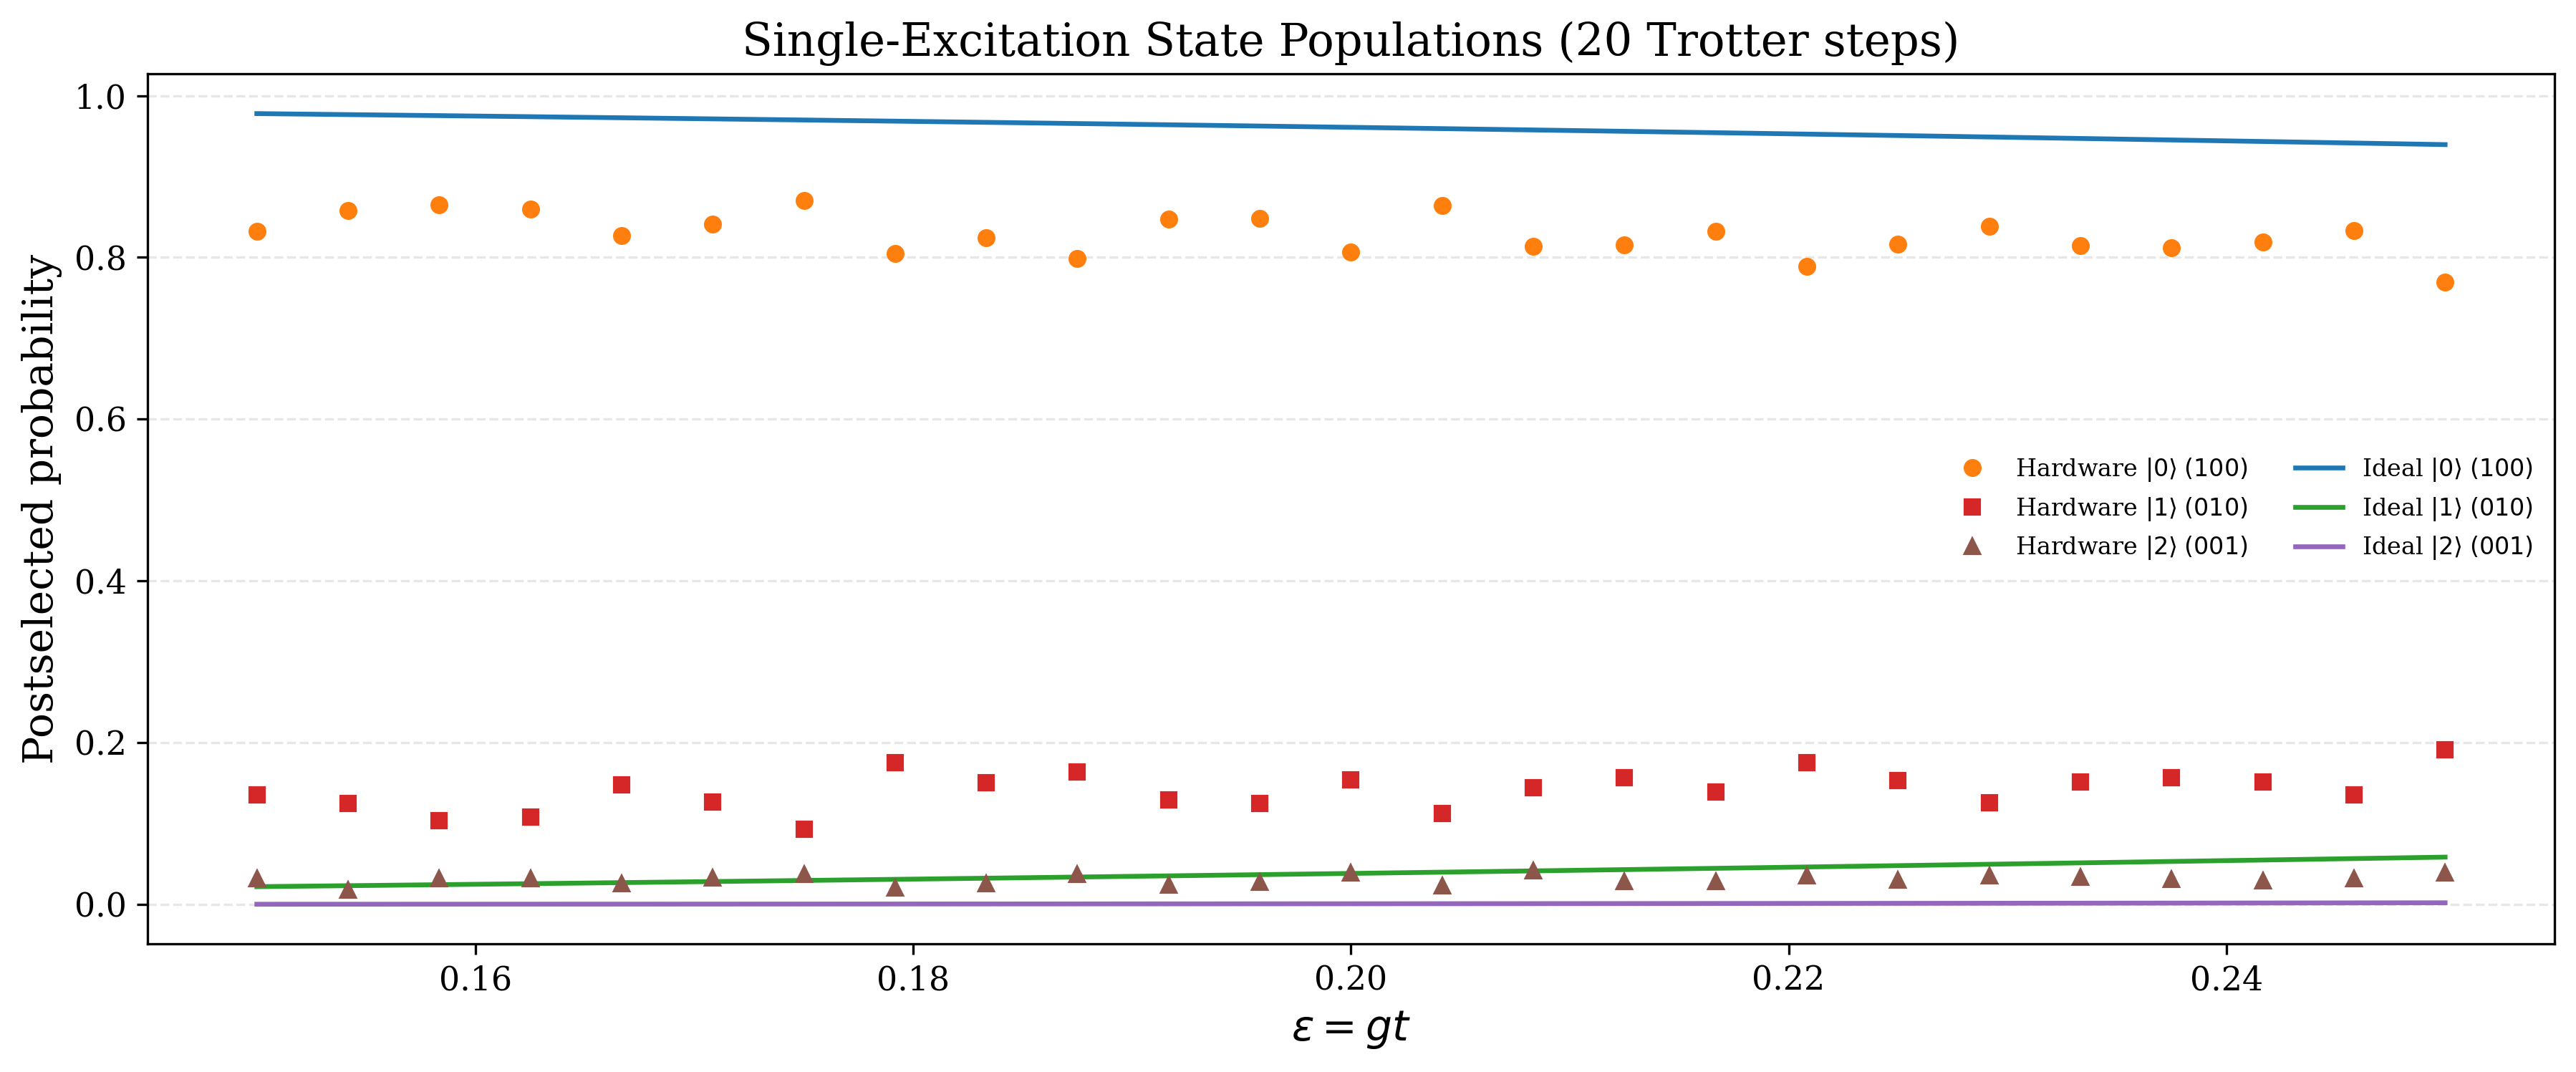

In [16]:
steps_value = troter_steps[0]

# Logical unary encoding
states = ['100', '010', '001']
logical_labels = [
    r'$|0\rangle\;(100)$',
    r'$|1\rangle\;(010)$',
    r'$|2\rangle\;(001)$'
]

eps_values = sorted(results[steps_value].keys())

fig, ax = plt.subplots(figsize=(12, 5))

markers = ['o', 's', '^']

hardware_lines = []
ideal_lines = []

for i, state in enumerate(states):

    ideal_y = []
    hardware_y = []

    for eps in eps_values:

        # Ideal Trotterized probabilities
        ideal = true_probs[steps_value][eps]
        norm = sum(ideal.get(s, 0) for s in states)

        ideal_y.append(
            ideal.get(state, 0) / norm if norm > 0 else 0
        )

        # Hardware postselected probabilities
        hardware = postselected_results[steps_value][eps]

        hardware_y.append(
            hardware.get(state, 0)
        )

    # Ideal curve
    ideal_line, = ax.plot(
        eps_values,
        ideal_y,
        linestyle='-',
        linewidth=1.6
    )

    # Hardware points
    hardware_line, = ax.plot(
        eps_values,
        np.array(hardware_y),
        linestyle='none',
        marker=markers[i],
        markersize=5
    )

    hardware_lines.append(hardware_line)
    ideal_lines.append(ideal_line)


ax.set_xlabel(r'$\epsilon = gt$')
ax.set_ylabel('Postselected probability')

ax.set_title(
    f'Single-Excitation State Populations '
    f'({steps_value} Trotter steps)'
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# Hardware first, Ideal second
handles = hardware_lines + ideal_lines

labels = (
    [rf'Hardware {label}' for label in logical_labels]
    +
    [rf'Ideal {label}' for label in logical_labels]
)

ax.legend(
    handles,
    labels,
    frameon=False,
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "plots/probability_vs_epsilon.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "plots/probability_vs_epsilon.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

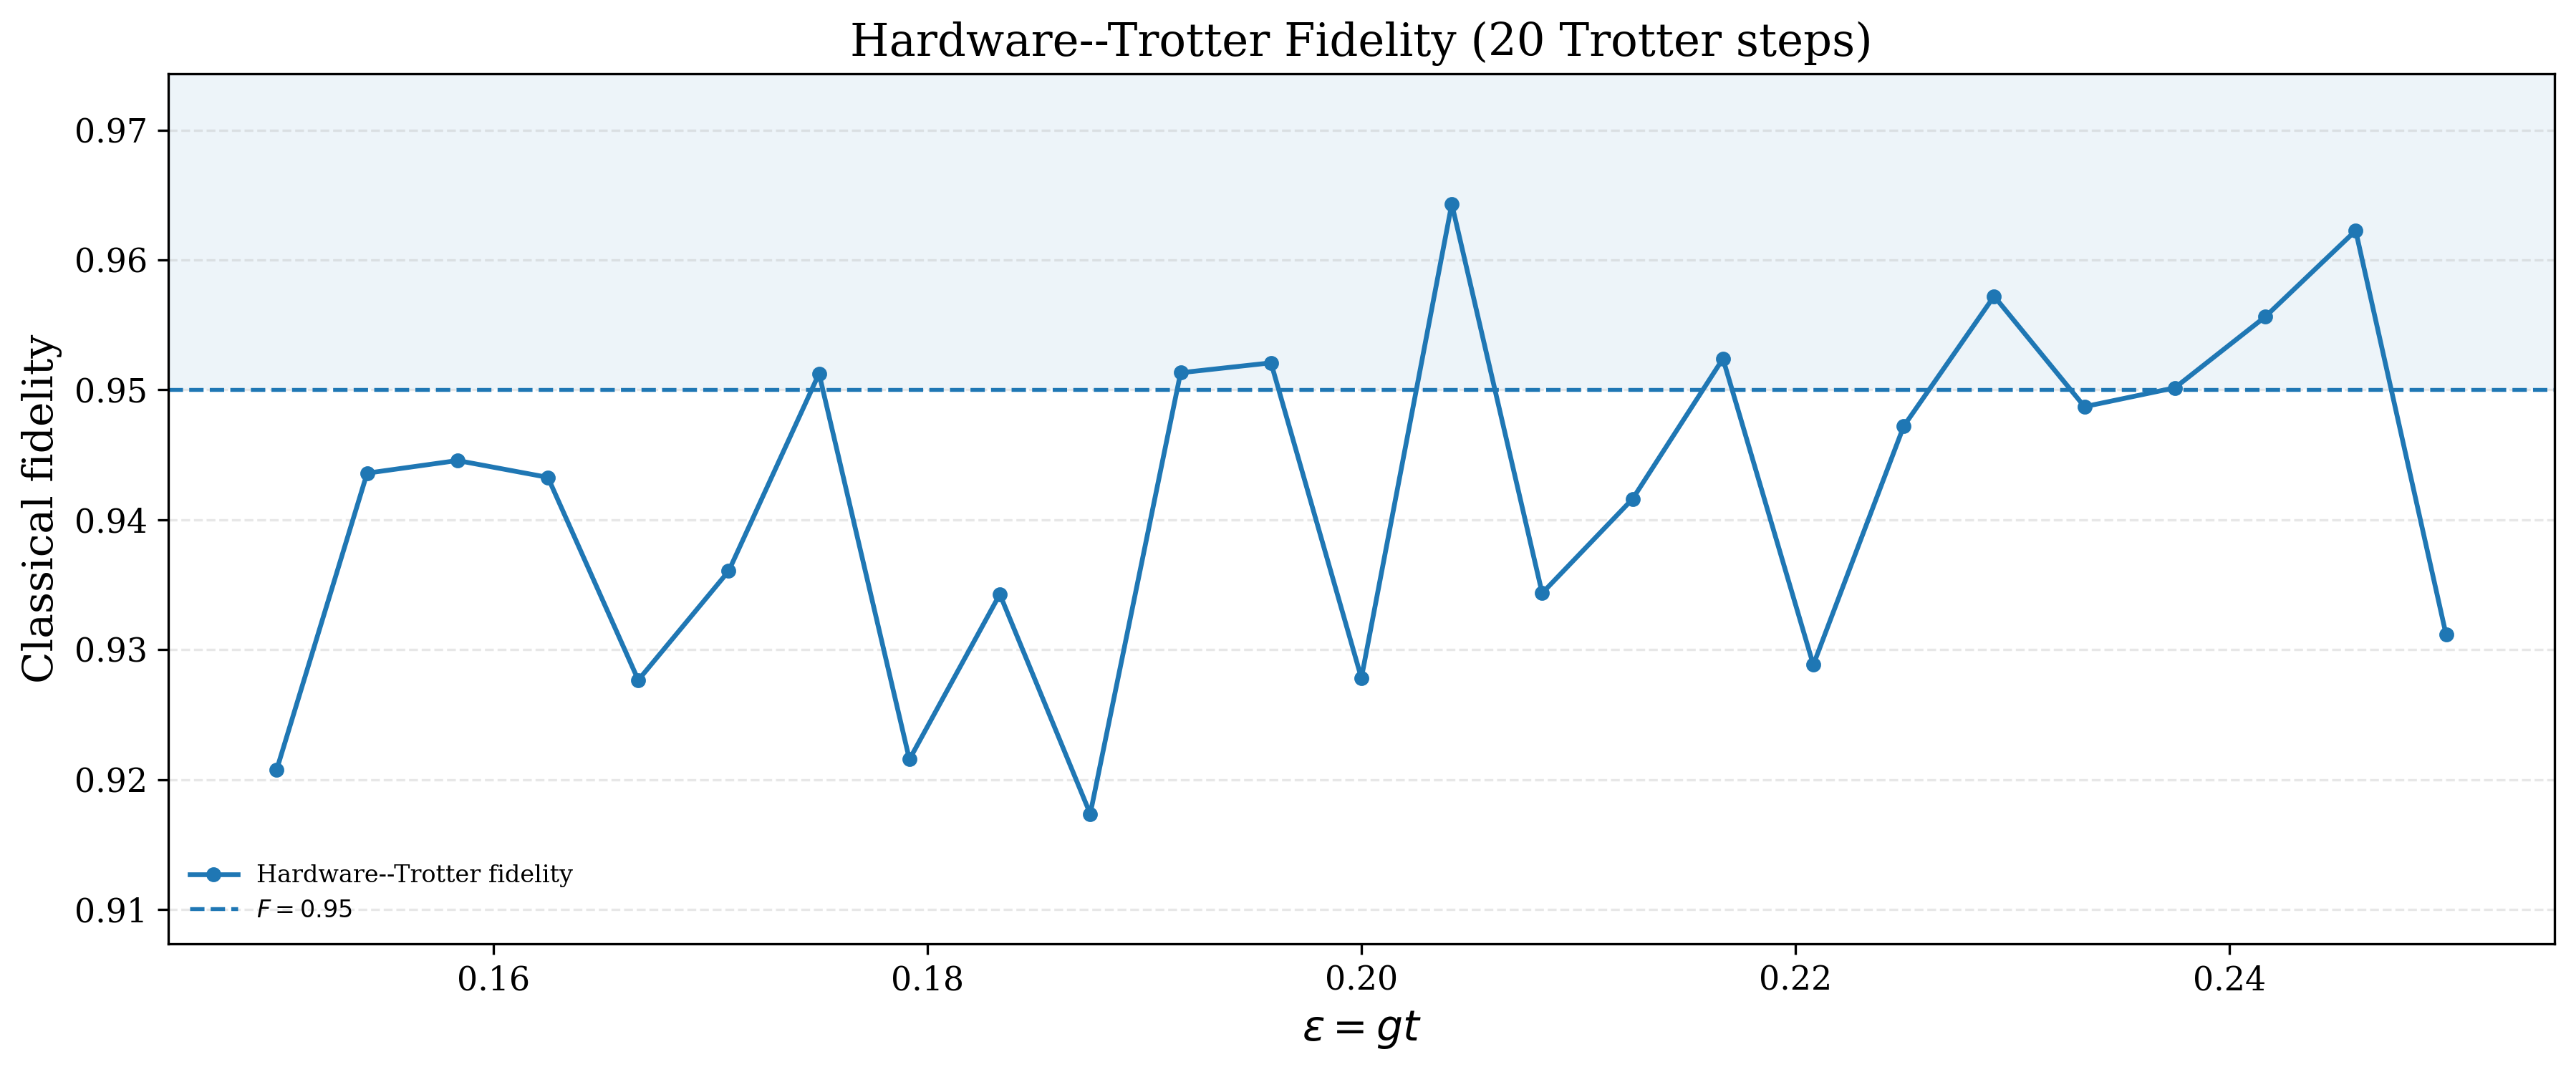

In [76]:
steps_value = troter_steps[0]

eps_values = sorted(fidelity_results[steps_value].keys())

fidelities = np.array([
    fidelity_results[steps_value][eps]
    for eps in eps_values
])

FIDELITY_THRESHOLD = 0.95

fig, ax = plt.subplots(figsize=(12, 5))

# Fidelity curve: Hardware vs. Trotter
ax.plot(
    eps_values,
    fidelities,
    marker='o',
    markersize=4,
    linewidth=1.6,
    label='Hardware--Trotter fidelity'
)

# 95% threshold
ax.axhline(
    FIDELITY_THRESHOLD,
    linestyle='--',
    linewidth=1.3,
    label=r'$F=0.95$'
)

# Highlight high-fidelity region
ax.axhspan(
    FIDELITY_THRESHOLD,
    1.0,
    alpha=0.08
)

# Zoom around the actual data
margin = 0.01

ymin = max(
    0.0,
    min(fidelities.min(), FIDELITY_THRESHOLD) - margin
)

ymax = min(
    1.0,
    max(fidelities.max(), FIDELITY_THRESHOLD) + margin
)

ax.set_ylim(ymin, ymax)

ax.set_xlabel(r'$\epsilon = gt$')
ax.set_ylabel('Classical fidelity')

ax.set_title(
    f'Hardware--Trotter Fidelity '
    f'({steps_value} Trotter steps)'
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "plots/fidelity_vs_epsilon.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "plots/fidelity_vs_epsilon.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

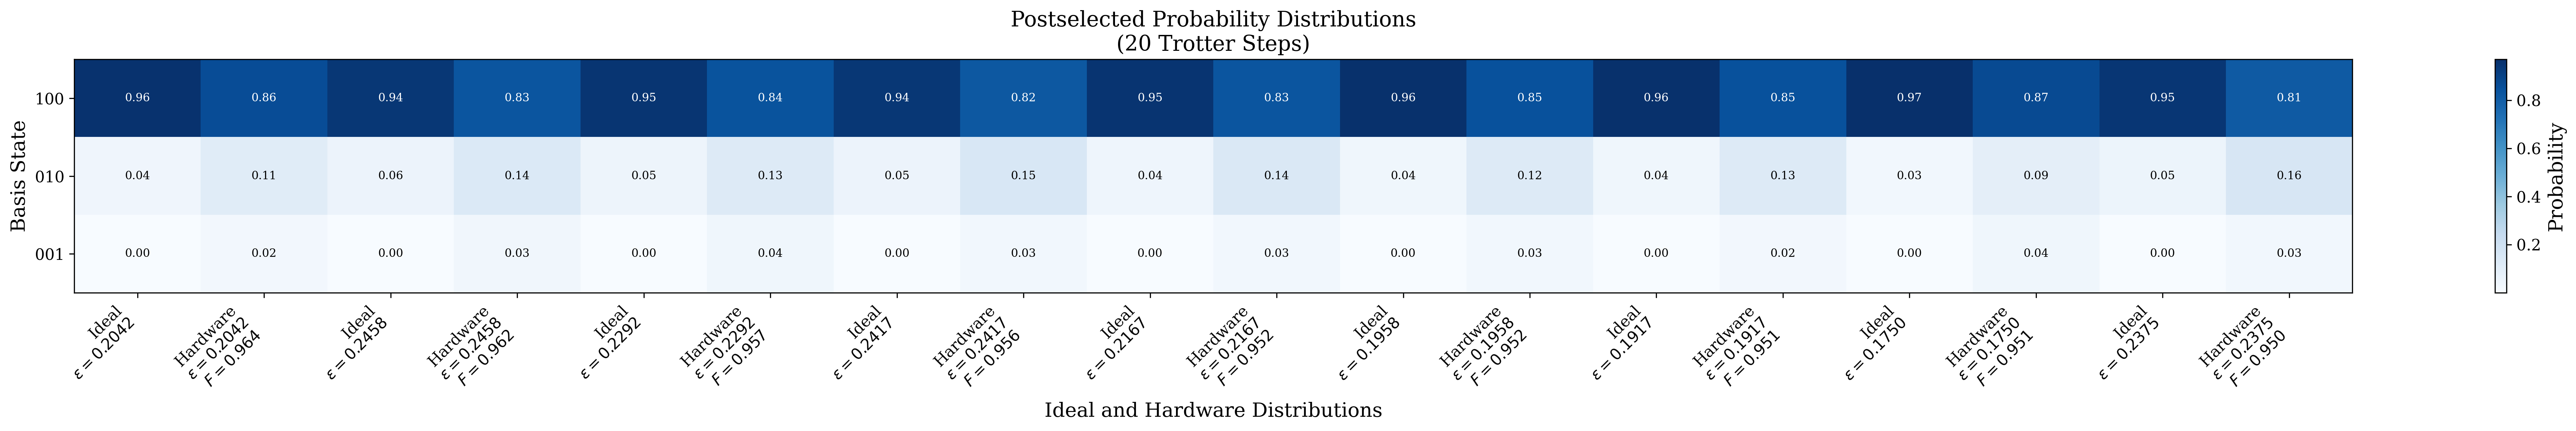

In [29]:
# Inputs

steps_value = troter_steps[0]
states = ['100', '010', '001']

selected_eps = [eps for eps, F in high_fidelity_eps]

heatmap_data = []
column_labels = []

# ==================================================
# Ideal + Hardware distributions for each epsilon
# ==================================================

for eps in selected_eps:

    # -------------------------------
    # Ideal Trotterized distribution
    # -------------------------------
    ideal = true_probs[steps_value][eps]

    norm = sum(
        ideal.get(state, 0)
        for state in states
    )

    ideal_probs = [
        ideal.get(state, 0) / norm
        if norm > 0 else 0
        for state in states
    ]

    heatmap_data.append(ideal_probs)

    column_labels.append(
        rf'Ideal' + "\n" +
        rf'$\epsilon={eps:.4f}$'
    )

    # -------------------------------
    # Hardware distribution
    # -------------------------------
    hardware = postselected_results[steps_value][eps]

    hardware_probs = [
        hardware.get(state, 0)
        for state in states
    ]

    heatmap_data.append(hardware_probs)

    fidelity = fidelity_results[steps_value][eps]

    column_labels.append(
        rf'Hardware' + "\n" +
        rf'$\epsilon={eps:.4f}$' + "\n" +
        rf'$F={fidelity:.3f}$'
    )

# ==================================================
# Convert to array
# Rows    -> basis states
# Columns -> Ideal/Hardware for each epsilon
# ==================================================

heatmap_data = np.array(heatmap_data).T

# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots(
    figsize=(
        1.5 * len(column_labels) + 2,
        0.8 * len(states) + 2
    )
)

im = ax.imshow(
    heatmap_data,
    cmap="Blues",
    aspect='auto',
    interpolation='nearest'
)

# X-axis

ax.set_xticks(np.arange(len(column_labels)))

ax.set_xticklabels(
    column_labels,
    rotation=45,
    ha='right'
)

# Y-axis

ax.set_yticks(np.arange(len(states)))
ax.set_yticklabels(states)

ax.set_xlabel("Ideal and Hardware Distributions")
ax.set_ylabel("Basis State")

ax.set_title(
    f"Postselected Probability Distributions\n"
    f"({steps_value} Trotter Steps)"
)

# Colorbar

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")

# ==================================================
# Annotate cells
# ==================================================

threshold = 0.5 * np.max(heatmap_data)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):

        value = heatmap_data[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            fontsize=8,
            color='white' if value > threshold else 'black'
        )

# Save

plt.tight_layout()

plt.savefig(
    "plots/probability_heatmap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "plots/probability_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

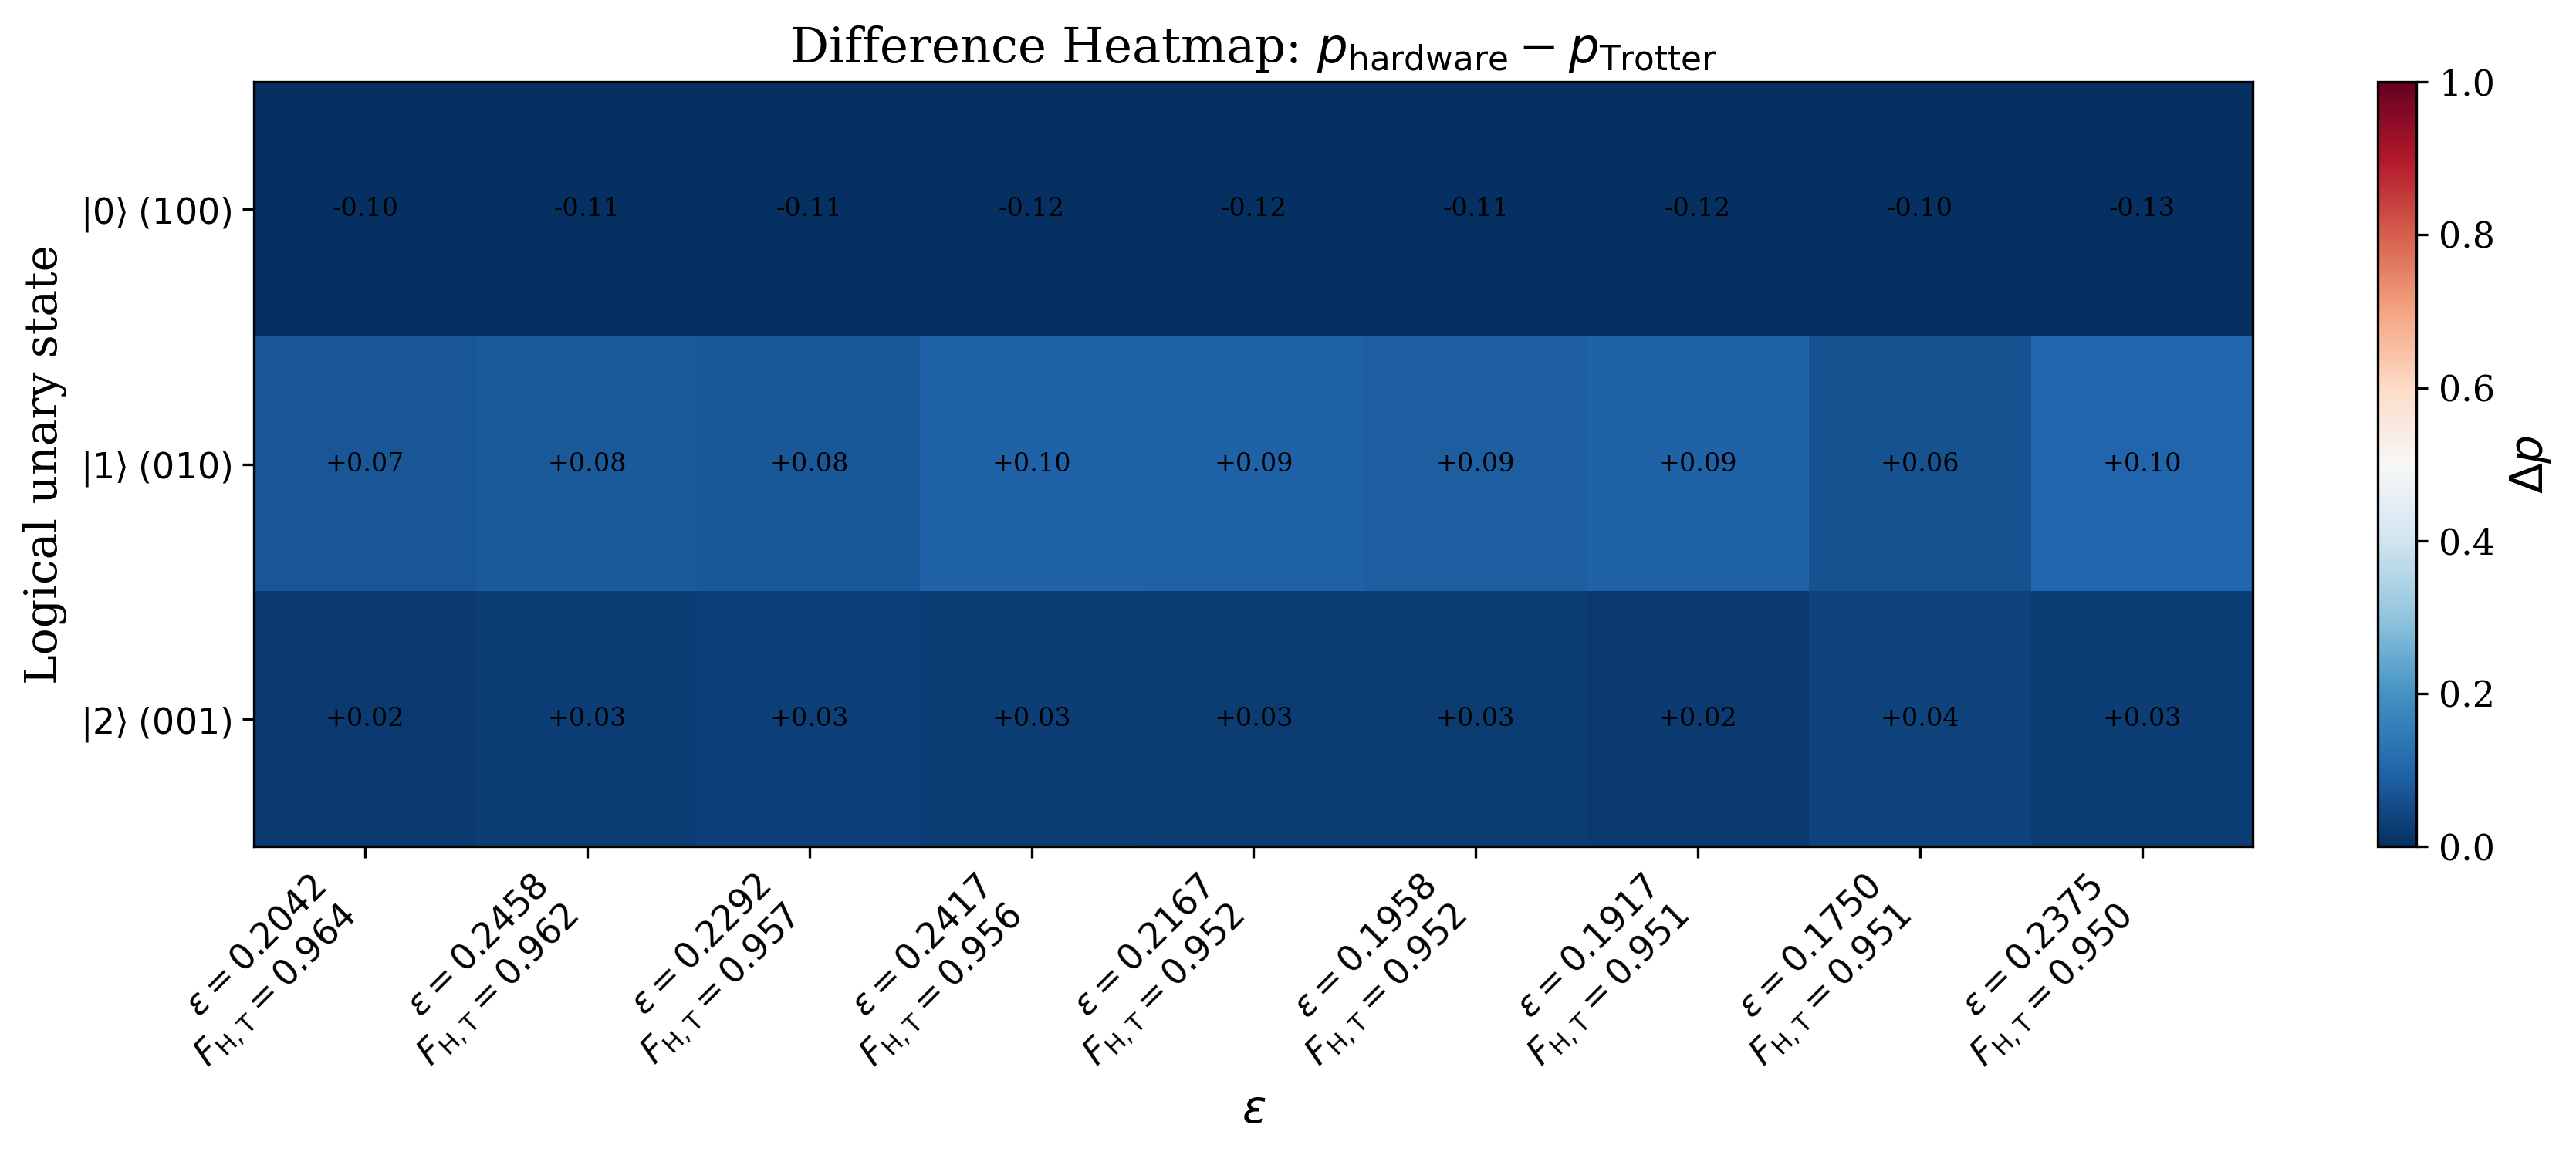

In [77]:
# ==================================================
# Inputs
# ==================================================

steps_value = troter_steps[0]

# Logical unary encoding
states = ['100', '010', '001']

logical_labels = [
    r'$|0\rangle\;(100)$',
    r'$|1\rangle\;(010)$',
    r'$|2\rangle\;(001)$'
]

selected_eps = [eps for eps, F in high_fidelity_eps]

# ==================================================
# Build Difference Matrix
# Rows    -> logical states
# Columns -> selected epsilon values
# ==================================================

difference_matrix = []
column_labels = []

for eps in selected_eps:

    # -----------------------------------------------
    # Trotterized probabilities
    # -----------------------------------------------
    trotter = true_probs[steps_value][eps]

    norm_true = sum(
        trotter.get(state, 0)
        for state in states
    )

    trotter_probs = np.array([
        trotter.get(state, 0) / norm_true
        if norm_true > 0 else 0
        for state in states
    ])

    # -----------------------------------------------
    # Hardware postselected probabilities
    # -----------------------------------------------
    hardware = postselected_results[steps_value][eps]

    hardware_probs = np.array([
        hardware.get(state, 0)
        for state in states
    ])

    # -----------------------------------------------
    # Hardware - Trotter difference
    # -----------------------------------------------
    delta = hardware_probs - trotter_probs

    difference_matrix.append(delta)

    fidelity = fidelity_results[steps_value][eps]

    column_labels.append(
        rf'$\epsilon={eps:.4f}$' + "\n" +
        rf'$F_{{\rm H,T}}={fidelity:.3f}$'
    )

# Convert to numpy array
difference_matrix = np.array(difference_matrix).T

# ==================================================
# Symmetric color scale around zero
# ==================================================

max_abs = np.max(np.abs(difference_matrix))

norm = plt.Normalize(
    vmin = 0 , # -max_abs
    # vcenter=0,
    vmax = 1 # max_abs
)

# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots(
    figsize=(12, 5)
)

im = ax.imshow(
    difference_matrix,
    cmap='RdBu_r',
    norm=norm,
    aspect='auto'
)

# --------------------------------------------------
# X-axis
# --------------------------------------------------

ax.set_xticks(np.arange(len(column_labels)))

ax.set_xticklabels(
    column_labels,
    rotation=45,
    ha='right'
)

# --------------------------------------------------
# Y-axis
# --------------------------------------------------

ax.set_yticks(np.arange(len(states)))

ax.set_yticklabels(logical_labels)

ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel('Logical unary state')

ax.set_title(
    r'Difference Heatmap: '
    r'$p_{\rm hardware}-p_{\rm Trotter}$'
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\Delta p$')

# --------------------------------------------------
# Cell values
# --------------------------------------------------

for i in range(difference_matrix.shape[0]):
    for j in range(difference_matrix.shape[1]):

        value = difference_matrix[i, j]

        ax.text(
            j,
            i,
            f"{value:+.2f}",
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )

# --------------------------------------------------
# Save
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "plots/difference_heatmap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "plots/difference_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#### **Calculate Analytical Probabilities**

In [48]:
# ============================================================
# Fidelity Analysis
# Analytical vs Trotter vs Hardware
# ============================================================

def analytical_probabilities(eps):

    theta = eps * np.sqrt(3)
    gup_coeff = 0.0001
    kappa = gup_coeff

    C0 = (
        (2 + np.cos(theta)) / 3
        + kappa * (
            (14/9) * (np.cos(theta) - 1)
            + (10/9) * theta * np.sin(theta)
        )
    )

    C1 = (
        1j / np.sqrt(3)
        * (
            np.sin(theta)
            + (10/3) * kappa
            * (np.sin(theta) - theta * np.cos(theta))
        )
    )

    C2 = (
        np.sqrt(2) / 3 * (np.cos(theta) - 1)
        + kappa * np.sqrt(2) / 9
        * (
            1
            + 8 * np.cos(theta)
            + 10 * theta * np.sin(theta)
        )
    )

    # Analytical basis-state mapping
    return {
        '100': abs(C0)**2,
        '010': abs(C1)**2,
        '001': abs(C2)**2
    }


def classical_fidelity(p1, p2):

    return (
        sum(
            np.sqrt(
                p1.get(state, 0.0) *
                p2.get(state, 0.0)
            )
            for state in allowed
        )
    ) ** 2


# ============================================================
# Storage
# ============================================================

fidelity_A_T = {}
fidelity_T_H = {}
fidelity_A_H = {}

postselection_fractions = {}


# ============================================================
# Calculate fidelities
# ============================================================

steps_value = troter_steps[0]

for eps in selected_eps:

    # --------------------------------------------------------
    # 1. ANALYTICAL
    # --------------------------------------------------------

    p_analytical = analytical_probabilities(eps)


    # --------------------------------------------------------
    # 2. IDEAL TROTTER
    # --------------------------------------------------------

    p_trotter_raw = true_probs[steps_value][eps]

    # Keep only the physical oscillator states
    # and map them consistently

    p_trotter = {
        state: p_trotter_raw.get(state, 0.0)
        for state in allowed
    }

    # Normalize
    norm_trotter = sum(p_trotter.values())

    if norm_trotter > 0:
        p_trotter = {
            state: p_trotter[state] / norm_trotter
            for state in allowed
        }


    # --------------------------------------------------------
    # 3. HARDWARE RAW COUNTS
    # --------------------------------------------------------

    raw_counts = results[steps_value][eps]


    # --------------------------------------------------------
    # 4. REVERSE QISKIT BITSTRINGS
    #
    # Qiskit:
    #   displayed '001' -> physical |100>
    #   displayed '010' -> physical |010>
    #   displayed '100' -> physical |001>
    # --------------------------------------------------------

    corrected_counts = {}

    for bitstring, count in raw_counts.items():

        corrected_state = bitstring[::-1]

        corrected_counts[corrected_state] = (
            corrected_counts.get(corrected_state, 0)
            + count
        )


    # --------------------------------------------------------
    # 5. POSTSELECT HARDWARE
    # --------------------------------------------------------

    post_counts = {
        state: corrected_counts.get(state, 0)
        for state in allowed
    }

    total_postselected = sum(post_counts.values())
    total_shots = sum(raw_counts.values())

    if total_postselected > 0:

        p_hardware = {
            state: post_counts[state] / total_postselected
            for state in allowed
        }

    else:

        p_hardware = {
            state: 0.0
            for state in allowed
        }


    # --------------------------------------------------------
    # 6. POSTSELECTION FRACTION
    # --------------------------------------------------------

    postselection_fraction = (
        total_postselected / total_shots
        if total_shots > 0 else 0
    )

    postselection_fractions[eps] = postselection_fraction


    # --------------------------------------------------------
    # 7. FIDELITIES
    # --------------------------------------------------------

    F_AT = classical_fidelity(
        p_analytical,
        p_trotter
    )

    F_TH = classical_fidelity(
        p_trotter,
        p_hardware
    )

    F_AH = classical_fidelity(
        p_analytical,
        p_hardware
    )


    fidelity_A_T[eps] = F_AT
    fidelity_T_H[eps] = F_TH
    fidelity_A_H[eps] = F_AH


    # --------------------------------------------------------
    # 8. PRINT
    # --------------------------------------------------------

    print("=" * 70)

    print(f"epsilon = {eps:.6f}")

    print("\nAnalytical:")
    for state in allowed:
        print(
            f"  {state}: "
            f"{p_analytical[state]:.8f}"
        )

    print("\nTrotter:")
    for state in allowed:
        print(
            f"  {state}: "
            f"{p_trotter[state]:.8f}"
        )

    print("\nHardware (bitstrings reversed):")
    for state in allowed:
        print(
            f"  {state}: "
            f"{p_hardware[state]:.8f}"
        )

    print(
        f"\nPostselection fraction = "
        f"{100 * postselection_fraction:.2f}%"
    )

    print(
        f"\nF(Analytical, Trotter) = "
        f"{100 * F_AT:.4f}%"
    )

    print(
        f"F(Trotter, Hardware) = "
        f"{100 * F_TH:.4f}%"
    )

    print(
        f"F(Analytical, Hardware) = "
        f"{100 * F_AH:.4f}%"
    )

    print("=" * 70)

epsilon = 0.204167

Analytical:
  100: 0.95918177
  010: 0.03997630
  001: 0.00084195

Trotter:
  100: 0.95918152
  010: 0.03989058
  001: 0.00092790

Hardware (bitstrings reversed):
  100: 0.86381323
  010: 0.11284047
  001: 0.02334630

Postselection fraction = 75.29%

F(Analytical, Trotter) = 99.9998%
F(Trotter, Hardware) = 96.4314%
F(Analytical, Hardware) = 96.4023%
epsilon = 0.245833

Analytical:
  100: 0.94137036
  010: 0.05687123
  001: 0.00175844

Trotter:
  100: 0.94136959
  010: 0.05669365
  001: 0.00193677

Hardware (bitstrings reversed):
  100: 0.83289474
  010: 0.13552632
  001: 0.03157895

Postselection fraction = 74.22%

F(Analytical, Trotter) = 99.9996%
F(Trotter, Hardware) = 96.2260%
F(Analytical, Hardware) = 96.1807%
epsilon = 0.229167

Analytical:
  100: 0.94884983
  010: 0.04981834
  001: 0.00133186

Trotter:
  100: 0.94884930
  010: 0.04968341
  001: 0.00146729

Hardware (bitstrings reversed):
  100: 0.83863369
  010: 0.12603062
  001: 0.03533569

Postselection frac

In [51]:
for eps in selected_eps:
    print("=" * 60)
    print(f"epsilon = {eps:.6f}")
    print("Raw counts:")
    print(results[steps_value][eps])

epsilon = 0.204167
Raw counts:
{'001': 666, '011': 87, '000': 85, '101': 30, '111': 41, '010': 87, '110': 10, '100': 18}
epsilon = 0.245833
Raw counts:
{'001': 633, '000': 94, '010': 103, '101': 38, '100': 24, '011': 88, '111': 32, '110': 12}
epsilon = 0.229167
Raw counts:
{'001': 712, '000': 57, '011': 55, '010': 107, '100': 30, '111': 33, '101': 23, '110': 7}
epsilon = 0.241667
Raw counts:
{'001': 671, '010': 124, '100': 24, '111': 21, '101': 32, '011': 60, '000': 79, '110': 13}
epsilon = 0.216667
Raw counts:
{'000': 106, '001': 617, '110': 11, '101': 49, '010': 103, '011': 80, '100': 21, '111': 37}
epsilon = 0.195833
Raw counts:
{'001': 652, '011': 97, '000': 86, '101': 25, '110': 14, '111': 33, '010': 96, '100': 21}
epsilon = 0.191667
Raw counts:
{'001': 643, '010': 98, '111': 40, '000': 99, '101': 30, '011': 82, '110': 14, '100': 18}
epsilon = 0.175000
Raw counts:
{'100': 29, '000': 106, '001': 676, '010': 72, '011': 75, '101': 28, '111': 30, '110': 8}
epsilon = 0.237500
Raw count

In [71]:
analytical_hardware_fidelity = {}

for eps in selected_eps:

    theta = eps * np.sqrt(3)

    C0 = (
        (2 + np.cos(theta)) / 3
        + gup_coeff * (
            (14/9) * (np.cos(theta) - 1)
            + (10/9) * theta * np.sin(theta)
        )
    )

    C1 = (
        1j / np.sqrt(3) * (
            np.sin(theta)
            + (10/3) * gup_coeff *
            (np.sin(theta) - theta * np.cos(theta))
        )
    )

    C2 = (
        np.sqrt(2) / 3 * (np.cos(theta) - 1)
        + gup_coeff * np.sqrt(2) / 9 *
        (1 + 8 * np.cos(theta)
         + 10 * theta * np.sin(theta))
    )

    p_analytical = {
        '100': abs(C0)**2,
        '010': abs(C1)**2,
        '001': abs(C2)**2
    }

    # Normalize
    total = sum(p_analytical.values())
    p_analytical = {
        k: v / total for k, v in p_analytical.items()
    }

    p_hardware = postselected_results[steps_value][eps]

    analytical_hardware_fidelity[eps] = classical_fidelity(
        p_analytical,
        p_hardware
    )

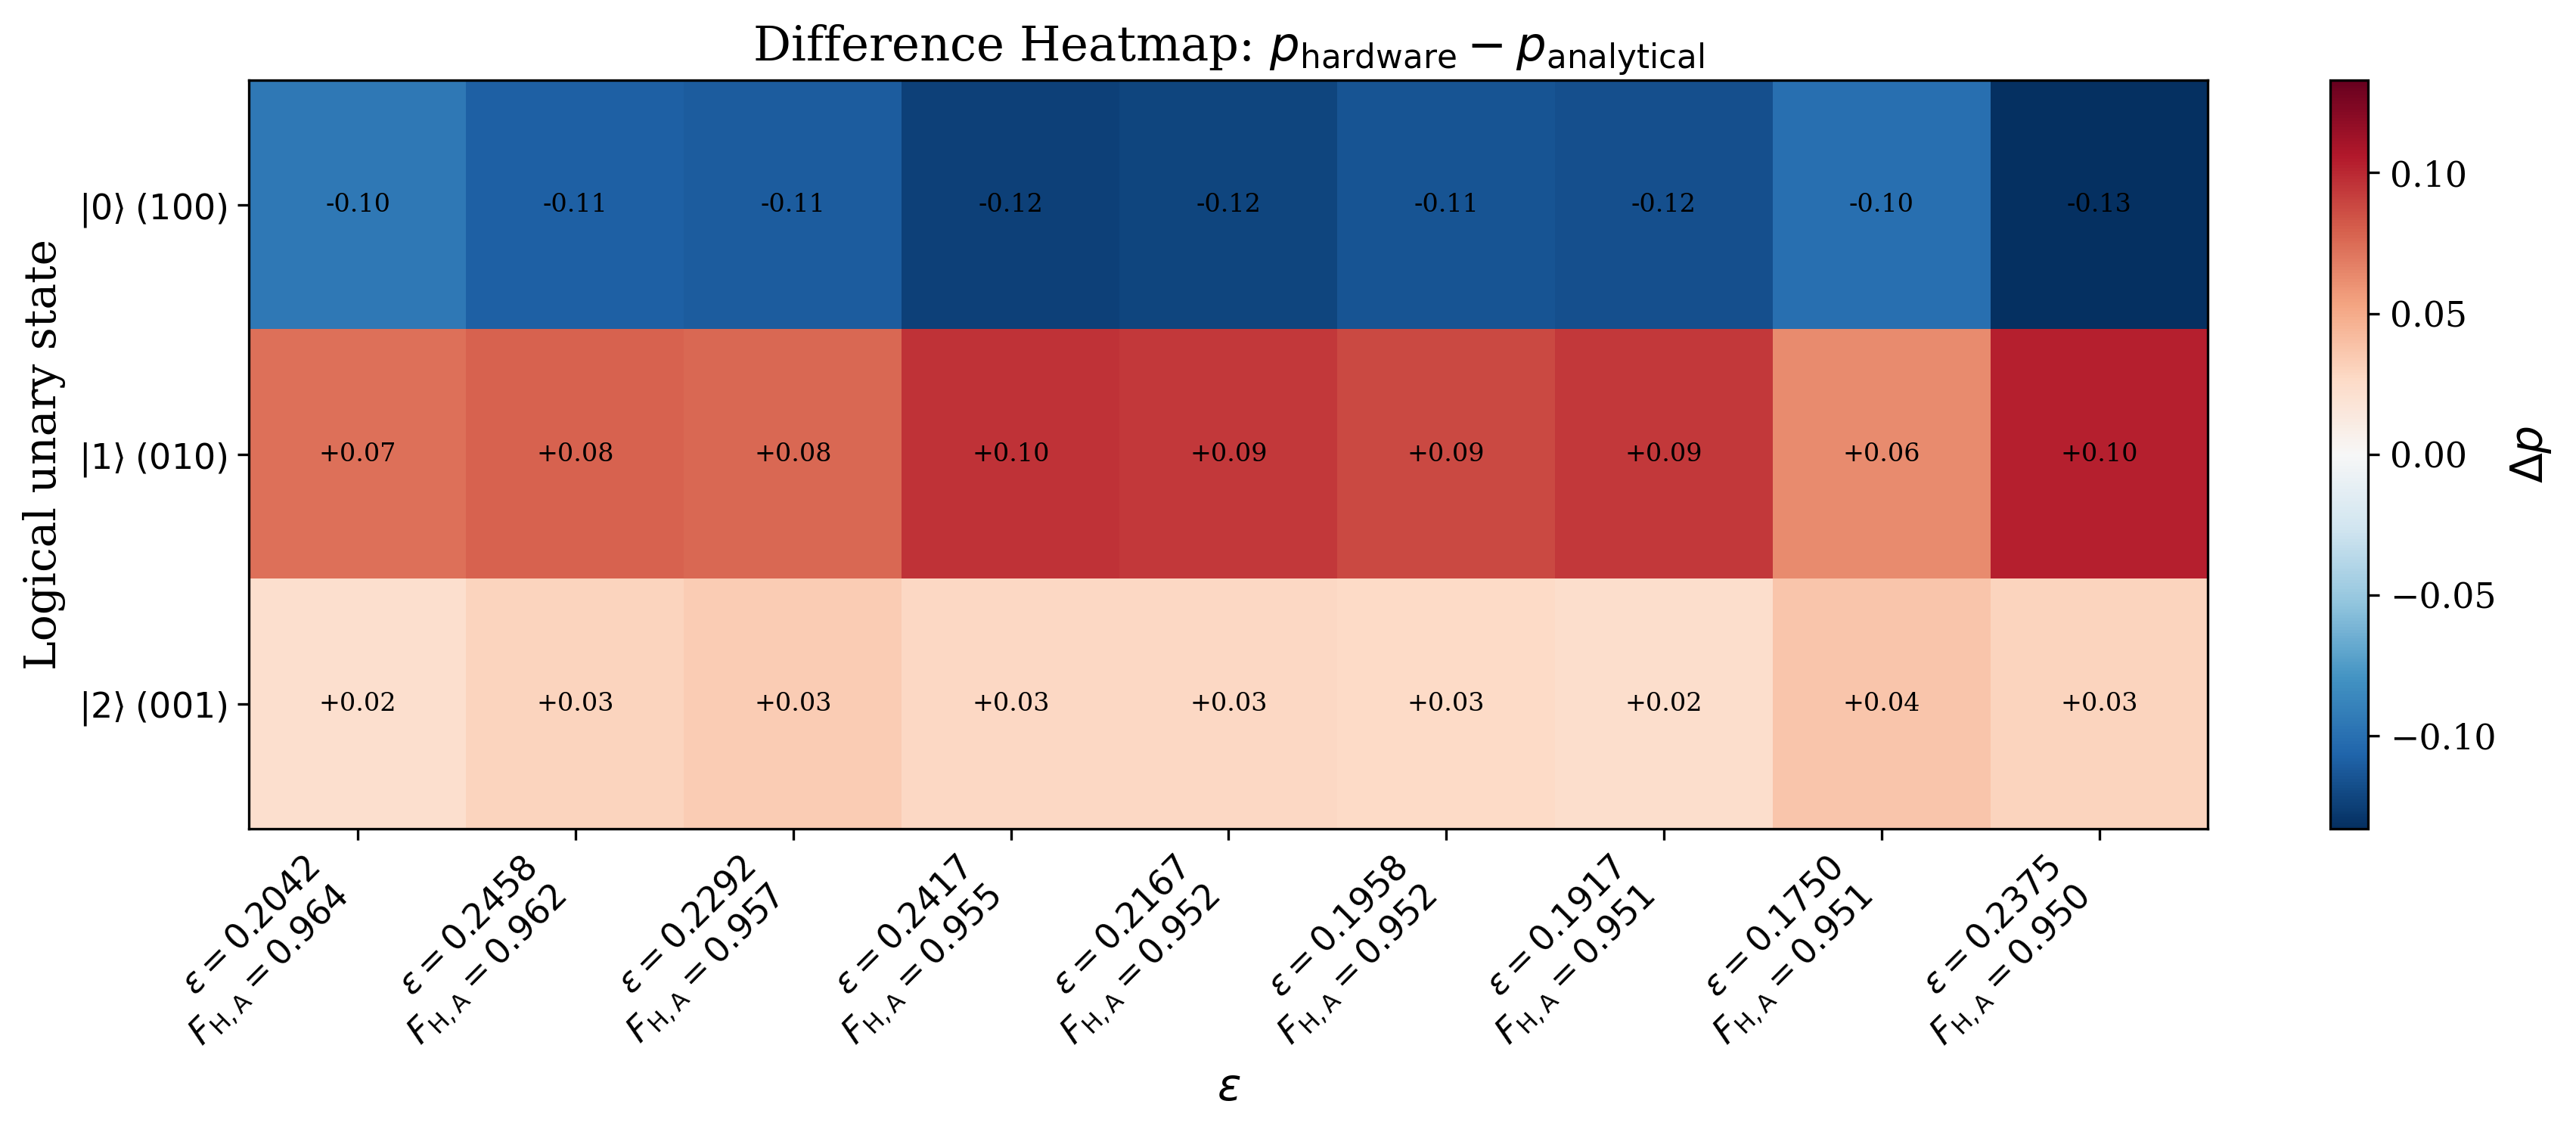

In [73]:
# ==================================================
# Inputs
# ==================================================

steps_value = troter_steps[0]

# Logical unary encoding
states = ['100', '010', '001']

logical_labels = [
    r'$|0\rangle\;(100)$',
    r'$|1\rangle\;(010)$',
    r'$|2\rangle\;(001)$'
]

selected_eps = [eps for eps, F in high_fidelity_eps]

gup_coeff = 0.0001

# ==================================================
# Build Difference Matrix
# Rows    -> logical states
# Columns -> selected epsilon values
# ==================================================

difference_matrix = []
column_labels = []

for eps in selected_eps:

    # -----------------------------------------------
    # Analytical probabilities
    # -----------------------------------------------

    theta = eps * np.sqrt(3)

    C0 = (
        (2 + np.cos(theta)) / 3
        + gup_coeff * (
            (14/9) * (np.cos(theta) - 1)
            + (10/9) * theta * np.sin(theta)
        )
    )

    C1 = (
        1j / np.sqrt(3) * (
            np.sin(theta)
            + (10/3) * gup_coeff *
            (np.sin(theta) - theta * np.cos(theta))
        )
    )

    C2 = (
        np.sqrt(2) / 3 * (np.cos(theta) - 1)
        + gup_coeff * np.sqrt(2) / 9 *
        (1 + 8 * np.cos(theta)
         + 10 * theta * np.sin(theta))
    )

    analytical_probs = np.array([
        abs(C0)**2,
        abs(C1)**2,
        abs(C2)**2
    ])

    # Normalize for numerical precision
    analytical_probs /= analytical_probs.sum()

    # -----------------------------------------------
    # Hardware postselected probabilities
    # -----------------------------------------------

    hardware = postselected_results[steps_value][eps]

    hardware_probs = np.array([
        hardware.get(state, 0)
        for state in states
    ])

    # -----------------------------------------------
    # Hardware - Analytical difference
    # -----------------------------------------------

    delta = hardware_probs - analytical_probs

    difference_matrix.append(delta)

    # Hardware-Analytical fidelity
    fidelity = analytical_hardware_fidelity[eps]

    column_labels.append(
        rf'$\epsilon={eps:.4f}$' + "\n" +
        rf'$F_{{\rm H,A}}={fidelity:.3f}$'
    )

# Convert to numpy array
difference_matrix = np.array(difference_matrix).T

# ==================================================
# Symmetric color scale around zero
# ==================================================

max_abs = np.max(np.abs(difference_matrix))

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs
)

# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots(
    figsize=(12, 5)
)

im = ax.imshow(
    difference_matrix,
    cmap='RdBu_r',
    norm=norm,
    aspect='auto'
)

# --------------------------------------------------
# X-axis
# --------------------------------------------------

ax.set_xticks(np.arange(len(column_labels)))

ax.set_xticklabels(
    column_labels,
    rotation=45,
    ha='right'
)

# --------------------------------------------------
# Y-axis
# --------------------------------------------------

ax.set_yticks(np.arange(len(states)))

ax.set_yticklabels(logical_labels)

ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel('Logical unary state')

ax.set_title(
    r'Difference Heatmap: '
    r'$p_{\rm hardware}-p_{\rm analytical}$'
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\Delta p$')

# --------------------------------------------------
# Cell values
# --------------------------------------------------

for i in range(difference_matrix.shape[0]):
    for j in range(difference_matrix.shape[1]):

        value = difference_matrix[i, j]

        ax.text(
            j,
            i,
            f"{value:+.2f}",
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )

# --------------------------------------------------
# Save
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "plots/difference_heatmap_hardware_analytical.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "plots/difference_heatmap_hardware_analytical.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()